# Human Annotation Analysis & LLM-as-a-Judge Comparison

This notebook covers:
1. **Annotation Form Overview** – what was being evaluated and on what scale
2. **Inter-Annotator Agreement** – Krippendorff's α, pairwise correlations, and annotator clustering
3. **Model Rankings from Human Annotations** – which LLM-generated analogies scored best
4. **Claude vs Human Annotators** – is Claude close to a particular annotator cluster?
5. **Claude Model Comparison** – which generator model scores highest according to Claude?

## Section 0 — Setup & Data Loading

In [24]:
import sys
print(sys.executable)

c:\Users\maria\AppData\Local\Programs\Python\Python311\python.exe


In [25]:
!{sys.executable} -m pip install krippendorff


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
import glob, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import krippendorff
from scipy import stats
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

# ── Colour palette (matches project style) ───────────────────────────────────
STEEL  = '#4682B4'
CORAL  = '#FF7F50'
AMBER  = '#E8A838'
GREEN  = '#5BA85B'
GRAY   = '#9E9E9E'
RED    = '#D9534F'
PURPLE = '#9467BD'
TEAL   = '#17BECF'

CLUSTER_COLORS = [STEEL, CORAL, AMBER, GREEN, PURPLE]

plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE   = os.path.dirname(os.path.abspath('__file__'))  # notebooks/
HA_DIR = os.path.join(BASE, '..', 'human_annotation')
RES_DIR = os.path.join(BASE, '..', 'results', 'human_annotation')
os.makedirs(RES_DIR, exist_ok=True)

CLAUDE_CSV = os.path.join(BASE, '..', 'results', 'upgraded_llm',
                          'upgraded_judge_3scale_fewshot_claude-sonnet-4.6.csv')
XLSX_FILE  = os.path.join(HA_DIR, '15_targets_full_data_with_reasoning.xlsx')
ANN_GLOB   = os.path.join(HA_DIR, 'human_results', '*.csv')

DIMS = ['coherence', 'mapping', 'explanatory']
CLAUDE_DIMS = ['analogy_coherence', 'mapping_soundness', 'explanatory_power']
DIM_LABELS = ['Coherence', 'Mapping', 'Explanatory']

print('Paths resolved. Output dir:', RES_DIR)

Paths resolved. Output dir: d:\My_working_area\Masters\Thesis\code\Toward-Usable-Scientific-Analogies\Toward-Usable-Scientific-Analogies\stage_2_Modular_solution\LLM\notebooks\..\results\human_annotation


In [54]:
# ── Load all 7 annotator CSVs ────────────────────────────────────────────────
ann_files = sorted(glob.glob(ANN_GLOB))
print(f'Found {len(ann_files)} annotator CSV files')

ann_dfs = []
for f in ann_files:
    df = pd.read_csv(f)
    ann_dfs.append(df)

human_df = pd.concat(ann_dfs, ignore_index=True)
human_df['analogy_key'] = human_df['source_analogy'].str.lower().str.strip()
human_df['target_key']  = human_df['target'].str.lower().str.strip()

annotators = sorted(human_df['annotator_id'].unique())
print(f'Annotators ({len(annotators)}): {annotators}')
print(f'Total rows: {len(human_df)} | Targets: {human_df["target"].nunique()} | Analogies per target: 3')

Found 7 annotator CSV files
Annotators (7): ['ANN-6JJP46', 'ANN-6LG7WY', 'ANN-DUNVTH', 'ANN-H2NTMS', 'ANN-KKN85E', 'ANN-Q777H6', 'ANN-VM9J6N']
Total rows: 315 | Targets: 15 | Analogies per target: 3


In [55]:
human_df

,annotator_id,target_id,target,domain,task_type,source_analogy,coherence,mapping,explanatory,rank,ranking_confidence,analogy_key,target_key
0,ANN-6JJP46,1,Gas Diffusion,Chemistry,full,perfume spreading,3,2,3,2,3,perfume spreading,gas diffusion
1,ANN-6JJP46,1,Gas Diffusion,Chemistry,full,smoke dispersion,3,3,3,1,3,smoke dispersion,gas diffusion
2,ANN-6JJP46,1,Gas Diffusion,Chemistry,full,gasoline,2,2,2,3,3,gasoline,gas diffusion
3,ANN-6JJP46,2,Encryption,CS,full,locked box,3,2,3,2,2,locked box,encryption
4,ANN-6JJP46,2,Encryption,CS,full,sealed envelope,3,3,3,1,2,sealed envelope,encryption
...,...,...,...,...,...,...,...,...,...,...,...,...,...
310,ANN-VM9J6N,14,Renaissance,History,full,Ancient Rome,1,2,1,3,3,ancient rome,renaissance
311,ANN-VM9J6N,14,Renaissance,History,full,Enlightenment,3,3,1,2,3,enlightenment,renaissance
312,ANN-VM9J6N,15,EM Algorithm,CS,full,detective investigation,3,3,2,1,1,detective investigation,em algorithm
313,ANN-VM9J6N,15,EM Algorithm,CS,full,guess‑and‑check,2,2,2,2,1,guess‑and‑check,em algorithm


In [56]:
# ── Load Excel (analogy → model/mode/type mapping) ───────────────────────────
xl_raw = pd.read_excel(XLSX_FILE, header=1)

# Rename the important columns
xl_raw.columns = (
    ['item_num', 'agreement_level', 'target', 'domain', 'quality_tier',
     'analogy', 'gen_model', 'gen_mode', 'analogy_type']
    + list(xl_raw.columns[9:])
)

# Forward-fill target info (only first row of each group is filled)
xl = xl_raw[['item_num','agreement_level','target','domain','quality_tier',
             'analogy','gen_model','gen_mode','analogy_type']].copy()
xl[['item_num','agreement_level','target','domain']] = (
    xl[['item_num','agreement_level','target','domain']].ffill()
)

xl['analogy_key'] = xl['analogy'].str.lower().str.strip()
xl['target_key']  = xl['target'].str.lower().str.strip()

print(f'Excel rows: {len(xl)} | Unique analogies: {xl["analogy_key"].nunique()}')
print('Quality tiers:', xl['quality_tier'].value_counts().to_dict())

Excel rows: 45 | Unique analogies: 45
Quality tiers: {'HIGH': 15, 'MIDDLE': 15, 'LOW': 15}


In [58]:
xl

,item_num,agreement_level,target,domain,quality_tier,analogy,gen_model,gen_mode,analogy_type,analogy_key,target_key
0,1.0,All Agree,Gas Diffusion,Chemistry,HIGH,Perfume spreading,gpt-oss-120b,targetonly,baseline,perfume spreading,gas diffusion
1,1.0,All Agree,Gas Diffusion,Chemistry,MIDDLE,Smoke dispersion,qwen3-14b,withsub,embedding,smoke dispersion,gas diffusion
2,1.0,All Agree,Gas Diffusion,Chemistry,LOW,Gasoline,qwen3-14b,targetonly,embedding,gasoline,gas diffusion
3,2.0,All Agree,Encryption,CS,HIGH,locked box,gpt-oss-120b,targetonly,baseline,locked box,encryption
4,2.0,All Agree,Encryption,CS,MIDDLE,Sealed envelope,grok-4-fast,withsub,rerank,sealed envelope,encryption
5,2.0,All Agree,Encryption,CS,LOW,Locker,gpt-4.1-nano,withsub,baseline,locker,encryption
6,3.0,All Agree,Industrial Revolution,History,HIGH,Steam engine era,gpt-oss-120b,targetonly,rerank,steam engine era,industrial revolution
7,3.0,All Agree,Industrial Revolution,History,MIDDLE,Automation,meta-llama-3-1-8b-instruct,withsub,baseline,automation,industrial revolution
8,3.0,All Agree,Industrial Revolution,History,LOW,Industrialization,llama-3.1-405b-instruct,targetonly,embedding,industrialization,industrial revolution
9,4.0,None Agree,GAN Algorithm,CS,HIGH,Art forgery,grok-4-fast,targetonly,rerank,art forgery,gan algorithm


In [29]:
# ── Load Claude judge CSV (lazy load: only needed columns) ───────────────────
print('Loading Claude CSV...')
claude_cols = ['target','model','original_mode','analogy_type','chosen_analogy',
               'analogy_coherence','mapping_soundness','explanatory_power',
               'average_score','status']
claude_df = pd.read_csv(CLAUDE_CSV, usecols=claude_cols)
claude_df = claude_df[claude_df['status'] == 'success'].copy()
claude_df['analogy_key'] = claude_df['chosen_analogy'].str.lower().str.strip()
claude_df['target_key']  = claude_df['target'].str.lower().str.strip()

print(f'Claude rows (success): {len(claude_df)}')
print('Models:', sorted(claude_df['model'].unique()))

Loading Claude CSV...
Claude rows (success): 25155
Models: ['deepseek-r1', 'gemini-2.5-flash-lite', 'gpt-4.1-mini', 'gpt-4.1-nano', 'gpt-oss-120b', 'gpt-oss-20b', 'grok-4-fast', 'llama-3.1-405b-instruct', 'meta-llama-3-1-70b-instruct', 'meta-llama-3-1-8b-instruct', 'qwen3-14b', 'qwen3-32b', 'retrieval-based']


---
## Section 1 — Annotation Form Overview

Human annotators used the following online form:  
👉 **[https://myriam2002.github.io/analogy-annotation/](https://myriam2002.github.io/analogy-annotation/)**

Each of the **7 annotators** was shown **15 scientific target concepts** and **3 candidate analogies** per concept (45 total). They rated each analogy on three independent dimensions and then provided a forced ranking.

In [30]:
# ── Rating dimensions reference table ────────────────────────────────────────
rating_info = pd.DataFrame({
    'Dimension': ['Coherence', 'Mapping', 'Explanatory Power'],
    'Question': [
        'How intuitive and understandable is the analogy?',
        'How well do source properties map onto the target concept?',
        'How much does the analogy help explain / teach the target?',
    ],
    '1 — Poor (🔴)': [
        'No clear connection; analogy feels unrelated',
        'No structural parallels; properties do not transfer',
        'Does not aid understanding; may even confuse',
    ],
    '2 — Partial (🟡)': [
        'Some connection, but superficial or incomplete',
        'Key properties map with gaps or exceptions',
        'Provides some insight but requires further explanation',
    ],
    '3 — Strong (🟢)': [
        'Clear, intuitive; familiar domain aligns naturally',
        'Strong, consistent structural correspondence',
        'Significantly enhances understanding with minimal extra explanation',
    ],
})
rating_info.set_index('Dimension', inplace=True)
print('=== Rating Dimension Definitions ===')
rating_info

=== Rating Dimension Definitions ===


,Question,1 — Poor (🔴),2 — Partial (🟡),3 — Strong (🟢)
Dimension,,,,
Coherence,How intuitive and understandable is the analogy?,No clear connection; analogy feels unrelated,"Some connection, but superficial or incomplete","Clear, intuitive; familiar domain aligns natur..."
Mapping,How well do source properties map onto the tar...,No structural parallels; properties do not tra...,Key properties map with gaps or exceptions,"Strong, consistent structural correspondence"
Explanatory Power,How much does the analogy help explain / teach...,Does not aid understanding; may even confuse,Provides some insight but requires further exp...,Significantly enhances understanding with mini...


In [31]:
# ── Target concepts summary ───────────────────────────────────────────────────
targets_summary = (
    human_df[['target_id','target','domain']]
    .drop_duplicates()
    .sort_values('target_id')
    .reset_index(drop=True)
)
print('=== 15 Target Concepts ===')
targets_summary

=== 15 Target Concepts ===


,target_id,target,domain
0,1,Gas Diffusion,Chemistry
1,2,Encryption,CS
2,3,Industrial Revolution,History
3,4,GAN Algorithm,CS
4,5,Bill of Rights,Law
5,6,AdaBoost Algorithm,CS
6,7,Platelets,Biology
7,8,Cell,Biology
8,9,Economics,Economics
9,10,Chemical Reaction,Chemistry


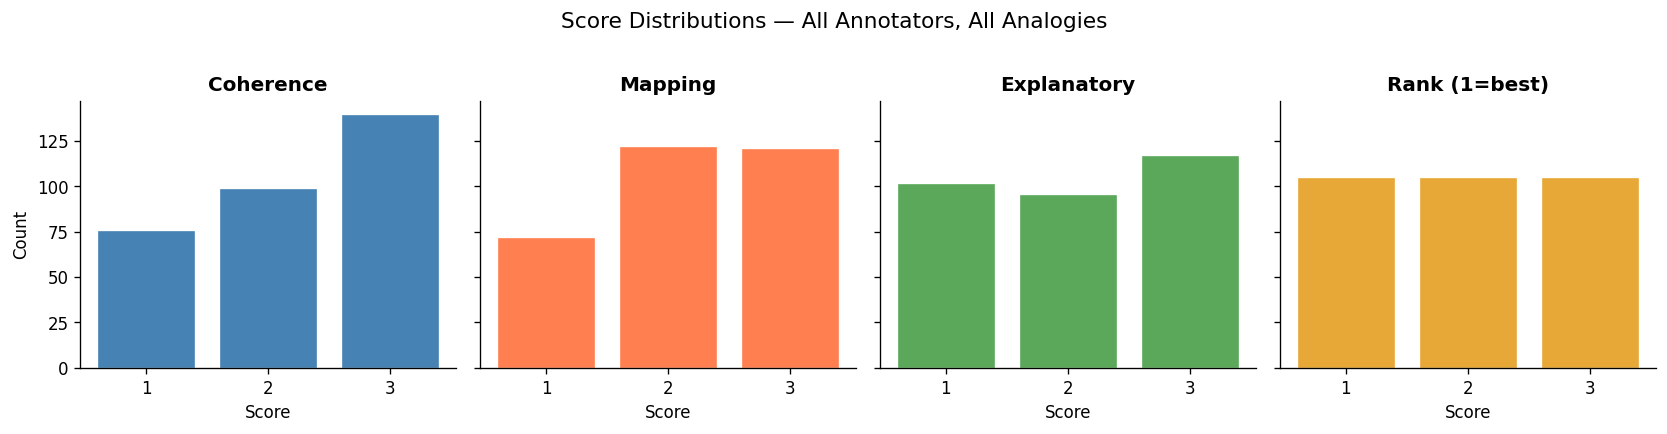

In [32]:
# ── Score distribution across all annotators ─────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), sharey=True)
plot_cols = DIMS + ['rank']
titles    = DIM_LABELS + ['Rank (1=best)']
colors    = [STEEL, CORAL, GREEN, AMBER]

for ax, col, title, color in zip(axes, plot_cols, titles, colors):
    counts = human_df[col].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color=color, edgecolor='white', linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel('Score')
    ax.set_ylabel('Count' if ax == axes[0] else '')

fig.suptitle('Score Distributions — All Annotators, All Analogies', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, 'score_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Section 2 — Inter-Annotator Agreement Analysis

In [60]:
# ── Build pivot tables (items × annotators) for each dimension ───────────────
# item key = target + analogy
human_df['item_key'] = human_df['target_key'] + ' | ' + human_df['analogy_key']

pivot = {}
for col in DIMS + ['rank']:
    pivot[col] = (
        human_df.pivot_table(index='item_key', columns='annotator_id', values=col)
        .sort_index()
    )

items = pivot['coherence'].index.tolist()
print(f'Items (analogies): {len(items)}  |  Annotators: {len(pivot["coherence"].columns)}')
pivot['coherence']

Items (analogies): 45  |  Annotators: 7


annotator_id,ANN-6JJP46,ANN-6LG7WY,ANN-DUNVTH,ANN-H2NTMS,ANN-KKN85E,ANN-Q777H6,ANN-VM9J6N
item_key,,,,,,,
adaboost algorithm | gears in a machine,2.0,1.0,2.0,1.0,1.0,2.0,1.0
adaboost algorithm | iterative training,3.0,2.0,2.0,2.0,3.0,2.0,3.0
adaboost algorithm | teamwork,3.0,3.0,3.0,3.0,2.0,3.0,3.0
bill of rights | new‑car warranty,3.0,2.0,2.0,1.0,1.0,2.0,1.0
bill of rights | rulebook,3.0,3.0,3.0,3.0,3.0,3.0,3.0
bill of rights | school curfew,2.0,2.0,2.0,1.0,1.0,1.0,1.0
cell | factory,3.0,3.0,2.0,2.0,3.0,2.0,3.0
cell | garage,1.0,1.0,1.0,1.0,1.0,3.0,1.0
cell | house,2.0,2.0,3.0,1.0,2.0,3.0,3.0


### 2A — Krippendorff's Alpha

In [34]:
def kripp_alpha(df, level_of_measurement='ordinal'):
    """Compute Krippendorff's alpha from an items×raters matrix."""
    # krippendorff expects raters × items
    data = df.values.T  # shape: (raters, items)
    return krippendorff.alpha(data, level_of_measurement=level_of_measurement)

alpha_results = {}
for col in DIMS + ['rank']:
    alpha_results[col] = kripp_alpha(pivot[col])

def interpret_alpha(a):
    if a < 0.0:  return 'No agreement'
    if a < 0.2:  return 'Slight'
    if a < 0.4:  return 'Fair'
    if a < 0.6:  return 'Moderate'
    if a < 0.8:  return 'Substantial'
    return 'Near-perfect'

alpha_df = pd.DataFrame({
    'Dimension': ['Coherence', 'Mapping', 'Explanatory', 'Rank'],
    'Krippendorff α (ordinal)': [alpha_results[c] for c in DIMS + ['rank']],
})
alpha_df['Interpretation'] = alpha_df['Krippendorff α (ordinal)'].apply(interpret_alpha)
alpha_df['Krippendorff α (ordinal)'] = alpha_df['Krippendorff α (ordinal)'].round(3)

print('=== Krippendorff\'s Alpha — All Dimensions ===')
alpha_df

=== Krippendorff's Alpha — All Dimensions ===


,Dimension,Krippendorff α (ordinal),Interpretation
0,Coherence,0.382,Fair
1,Mapping,0.342,Fair
2,Explanatory,0.381,Fair
3,Rank,0.479,Moderate


In [110]:
from scipy.stats import chi2 as chi2_dist

def kendall_w(rankings_matrix):
    m, n = rankings_matrix.shape
    rank_sums = rankings_matrix.sum(axis=0)
    S = np.sum((rank_sums - rank_sums.mean()) ** 2)
    W = 12 * S / (m**2 * (n**3 - n))
    chi2_stat = m * (n - 1) * W
    p_val = chi2_dist.sf(chi2_stat, df=n - 1)
    return W, p_val

rank_pivot = human_df.pivot_table(
    index=['target_key', 'analogy_key'],
    columns='annotator_id',
    values='rank'
)

kendall_rows = []
for target in rank_pivot.index.get_level_values('target_key').unique():
    target_data = rank_pivot.loc[target]           # rows = analogies
    analogies   = target_data.index.tolist()       # the 3 analogy names
    mat = target_data.values.T                     # (raters, 3 analogies)
    valid = mat[~np.isnan(mat).any(axis=1)]
    if valid.shape[0] >= 2 and valid.shape[1] == 3:
        w, p = kendall_w(valid)
        kendall_rows.append({
            'Target':       target,
            'Analogy 1':    analogies[0],
            'Analogy 2':    analogies[1],
            'Analogy 3':    analogies[2],
            "Kendall's W":  round(w, 3),
            'p-value':      round(p, 4),
        })

kendall_df = pd.DataFrame(kendall_rows).set_index('Target')
mean_w, mean_p = kendall_df["Kendall's W"].mean(), kendall_df['p-value'].mean()

print(f"=== Kendall's W — Rank Agreement across 3 Analogies ===")
print(f"Mean W = {mean_w:.3f}  |  Mean p = {mean_p:.4f}\n")
kendall_df


=== Kendall's W — Rank Agreement across 3 Analogies ===
Mean W = 0.552  |  Mean p = 0.1816



,Analogy 1,Analogy 2,Analogy 3,Kendall's W,p-value
Target,,,,,
adaboost algorithm,gears in a machine,iterative training,teamwork,0.735,0.0058
bill of rights,new‑car warranty,rulebook,school curfew,0.388,0.0663
cell,factory,garage,house,0.551,0.0211
chemical reaction,baking soda + vinegar,boiling water,digestion,0.878,0.0021
economics,ecosystem,household budget,marketplace,0.020,0.8669
em algorithm,detective investigation,guess‑and‑check,miner,0.755,0.0051
encryption,locked box,locker,sealed envelope,0.143,0.3679
gan algorithm,art forgery,artist and critic,teacher,0.878,0.0021
gas diffusion,gasoline,perfume spreading,smoke dispersion,0.796,0.0038


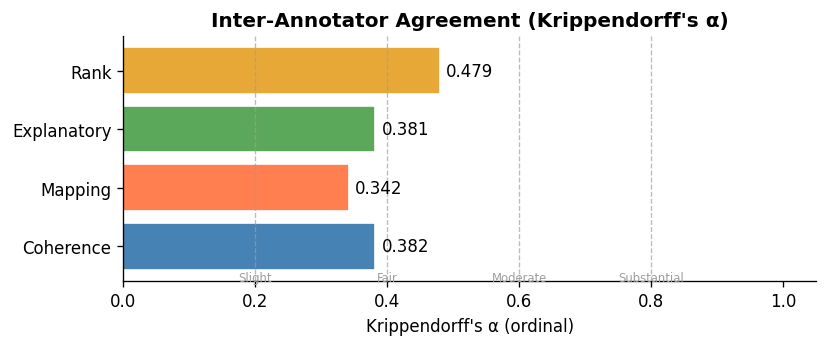

In [35]:
# ── Visualise alphas ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3))
dim_labels_all = ['Coherence', 'Mapping', 'Explanatory', 'Rank']
alphas = [alpha_results[c] for c in DIMS + ['rank']]
bar_colors = [STEEL, CORAL, GREEN, AMBER]

bars = ax.barh(dim_labels_all, alphas, color=bar_colors, edgecolor='white')
for bar, val in zip(bars, alphas):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

# Reference lines
for x, lbl in [(0.2, 'Slight'), (0.4, 'Fair'), (0.6, 'Moderate'), (0.8, 'Substantial')]:
    ax.axvline(x, color=GRAY, linestyle='--', linewidth=0.8, alpha=0.7)
    ax.text(x, -0.6, lbl, ha='center', fontsize=7, color=GRAY)

ax.set_xlim(0, 1.05)
ax.set_xlabel("Krippendorff's α (ordinal)")
ax.set_title("Inter-Annotator Agreement (Krippendorff's α)")
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, 'krippendorff_alpha.png'), dpi=150, bbox_inches='tight')
plt.show()

### 2B — Pairwise Annotator Correlations (Spearman)

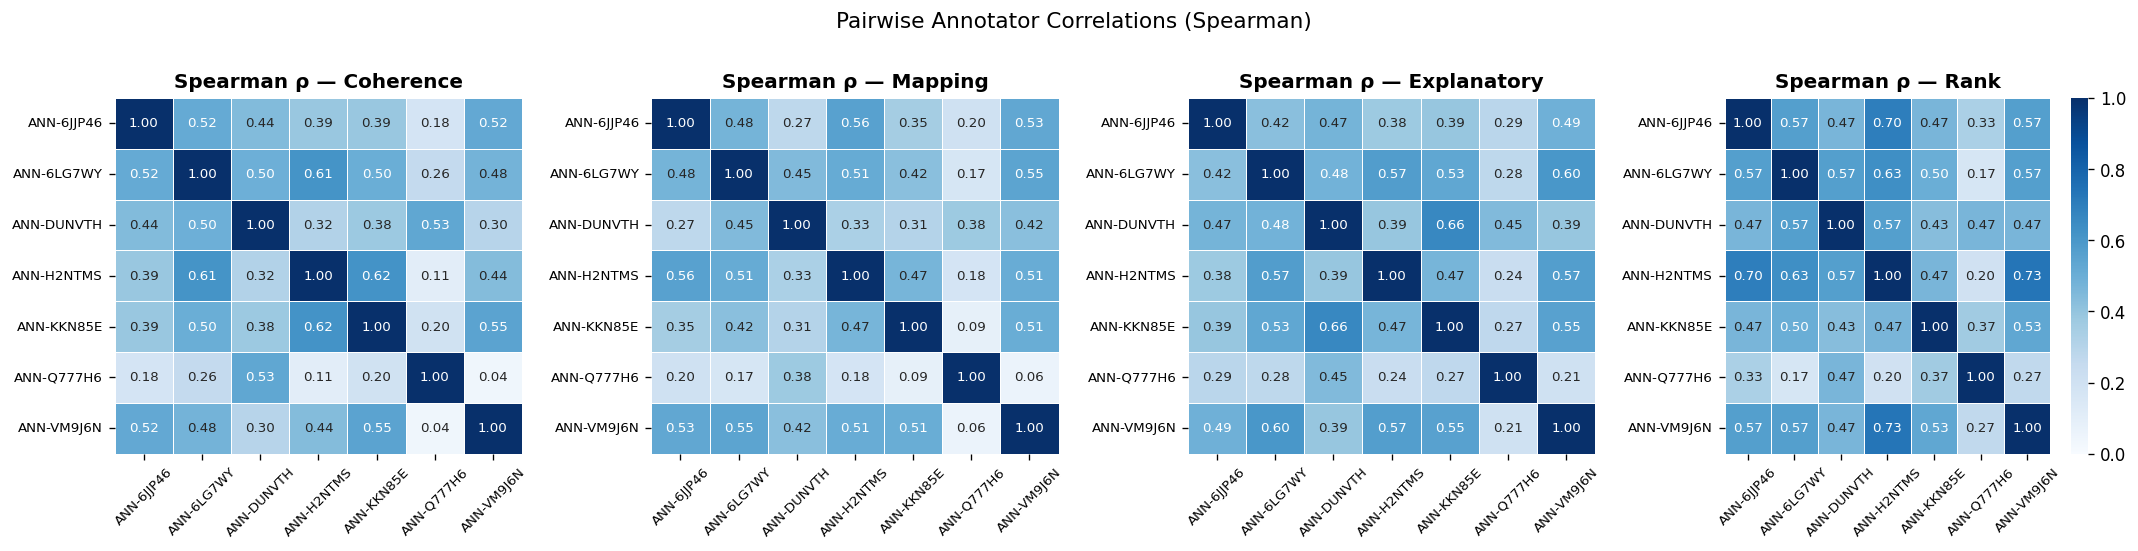

In [36]:
def pairwise_spearman(df):
    """Return (n_ann × n_ann) Spearman ρ matrix."""
    cols = df.columns.tolist()
    n = len(cols)
    mat = np.eye(n)
    for i in range(n):
        for j in range(i+1, n):
            rho, _ = stats.spearmanr(df.iloc[:, i], df.iloc[:, j], nan_policy='omit')
            mat[i, j] = mat[j, i] = rho
    return pd.DataFrame(mat, index=cols, columns=cols)

corr_mats = {col: pairwise_spearman(pivot[col]) for col in DIMS + ['rank']}

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, col, title in zip(axes, DIMS + ['rank'], DIM_LABELS + ['Rank']):
    sns.heatmap(corr_mats[col], annot=True, fmt='.2f', cmap='Blues',
                vmin=0, vmax=1, linewidths=0.5, ax=ax,
                cbar=ax == axes[-1], annot_kws={'size': 8})
    ax.set_title(f'Spearman ρ — {title}')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)

fig.suptitle('Pairwise Annotator Correlations (Spearman)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, 'pairwise_correlations.png'), dpi=150, bbox_inches='tight')
plt.show()

### 2C — Annotator Clustering

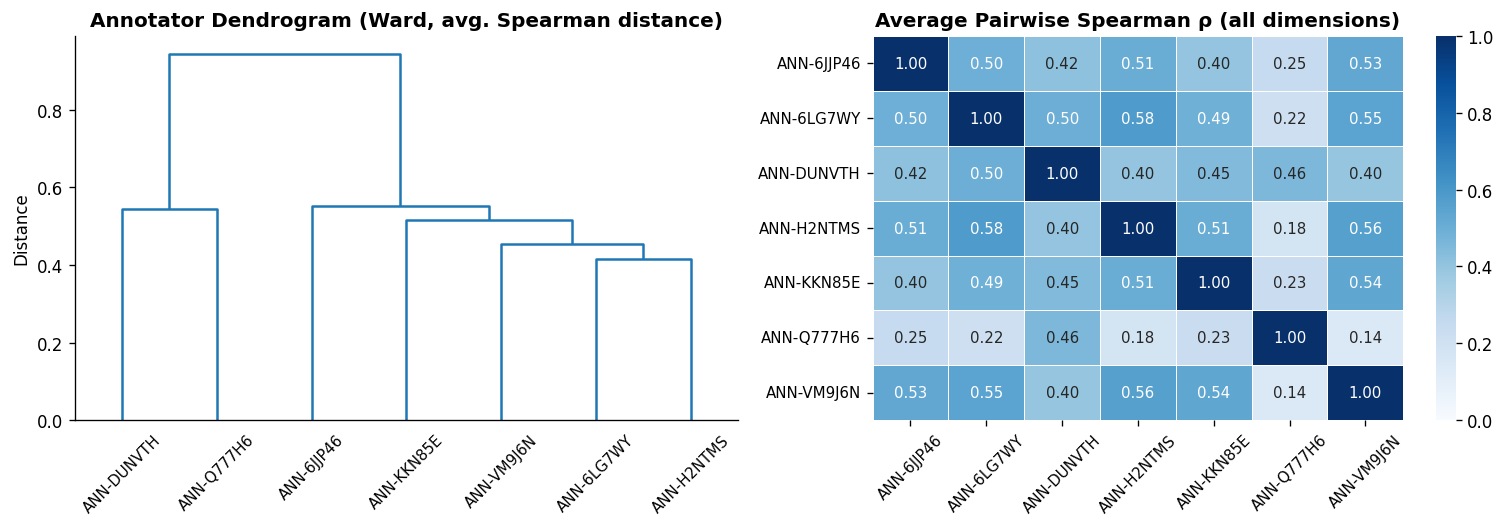

In [37]:
# ── Build per-annotator feature vectors (mean score per dimension) ────────────
# Use the average correlation across all dimensions as the distance basis
avg_corr = np.mean([corr_mats[c].values for c in DIMS + ['rank']], axis=0)
avg_corr_df = pd.DataFrame(avg_corr, index=corr_mats['coherence'].index,
                            columns=corr_mats['coherence'].columns)

# Convert correlation to distance, ensure symmetry & clip negatives
dist_mat = 1 - avg_corr
np.fill_diagonal(dist_mat, 0)
dist_mat = np.clip(dist_mat, 0, None)
condensed = squareform(dist_mat)

linkage_mat = linkage(condensed, method='ward')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Dendrogram
ann_labels = avg_corr_df.index.tolist()
dend = dendrogram(linkage_mat, labels=ann_labels, ax=ax1,
                  color_threshold=0.3 * linkage_mat[-1, 2],
                  leaf_font_size=9)
ax1.set_title('Annotator Dendrogram (Ward, avg. Spearman distance)')
ax1.set_ylabel('Distance')
ax1.tick_params(axis='x', rotation=45)

# Average correlation heatmap
sns.heatmap(avg_corr_df, annot=True, fmt='.2f', cmap='Blues',
            vmin=0, vmax=1, linewidths=0.5, ax=ax2, annot_kws={'size': 9})
ax2.set_title('Average Pairwise Spearman ρ (all dimensions)')
ax2.tick_params(axis='x', rotation=45, labelsize=9)
ax2.tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, 'annotator_clustering.png'), dpi=150, bbox_inches='tight')
plt.show()

In [38]:
# ── Assign cluster labels (cut dendrogram at k clusters) ─────────────────────
# Try k=2 and k=3; choose the one with the largest gap in linkage heights
heights = linkage_mat[:, 2]
gaps = np.diff(heights)
best_k = np.argmax(gaps[-3:]) + 2  # look at last 3 merges → 2, 3, or 4 clusters
print(f'Suggested k = {best_k}  (largest linkage gap)')

cluster_labels = fcluster(linkage_mat, best_k, criterion='maxclust')
ann_to_cluster = dict(zip(ann_labels, cluster_labels))
print('Cluster assignments:', ann_to_cluster)

# Build a per-annotator profile DataFrame
ann_profile = []
for ann in ann_labels:
    sub = human_df[human_df['annotator_id'] == ann]
    row = {'annotator': ann, 'cluster': ann_to_cluster[ann]}
    for d in DIMS + ['rank', 'ranking_confidence']:
        row[f'mean_{d}'] = sub[d].mean()
        row[f'std_{d}']  = sub[d].std()
    ann_profile.append(row)

ann_profile_df = pd.DataFrame(ann_profile).sort_values('cluster')
display_cols = ['annotator', 'cluster'] + [f'mean_{d}' for d in DIMS] + ['mean_rank']
ann_profile_df[display_cols].round(2)

Suggested k = 4  (largest linkage gap)
Cluster assignments: {'ANN-6JJP46': 4, 'ANN-6LG7WY': 3, 'ANN-DUNVTH': 1, 'ANN-H2NTMS': 3, 'ANN-KKN85E': 3, 'ANN-Q777H6': 2, 'ANN-VM9J6N': 3}


,annotator,cluster,mean_coherence,mean_mapping,mean_explanatory,mean_rank
2,ANN-DUNVTH,1,2.38,1.91,1.98,2.0
5,ANN-Q777H6,2,2.27,2.27,2.24,2.0
1,ANN-6LG7WY,3,2.11,2.27,1.89,2.0
3,ANN-H2NTMS,3,1.93,1.96,1.62,2.0
4,ANN-KKN85E,3,2.13,2.11,2.11,2.0
6,ANN-VM9J6N,3,2.24,2.38,1.98,2.0
0,ANN-6JJP46,4,2.36,2.20,2.51,2.0


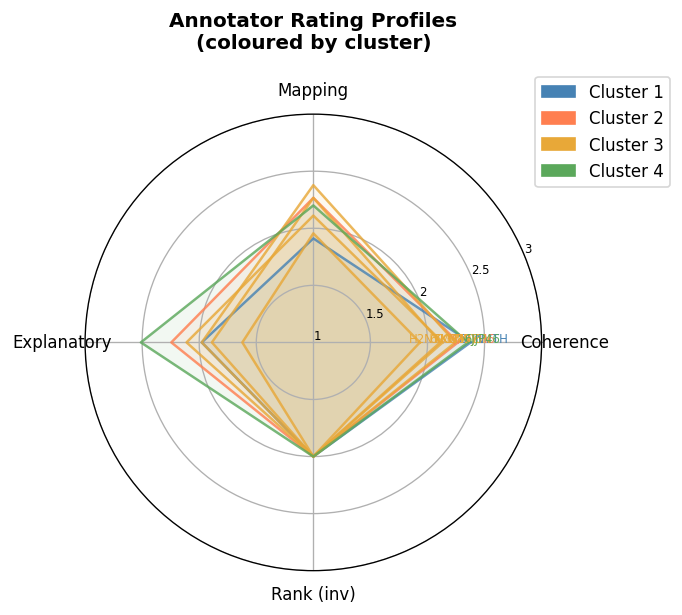

In [39]:
# ── Radar chart per annotator (and per cluster mean) ─────────────────────────
radar_dims  = DIMS + ['rank']  # 4 axes; note rank is inverted (lower = better)
radar_labels = DIM_LABELS + ['Rank (inv)']
N = len(radar_dims)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the loop

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

for _, row in ann_profile_df.iterrows():
    c = row['cluster']
    # For rank: invert so higher = better (max rank=3 → plot as 1, min rank=1 → plot as 3)
    vals = [row[f'mean_{d}'] for d in DIMS] + [4 - row['mean_rank']]
    vals += vals[:1]
    color = CLUSTER_COLORS[c - 1]
    ax.plot(angles, vals, color=color, linewidth=1.5, alpha=0.8)
    ax.fill(angles, vals, color=color, alpha=0.08)
    ax.text(angles[0], vals[0] + 0.12, row['annotator'].split('-')[-1],
            ha='center', fontsize=7, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=10)
ax.set_ylim(1, 3)
ax.set_yticks([1, 1.5, 2, 2.5, 3])
ax.set_yticklabels(['1', '1.5', '2', '2.5', '3'], fontsize=7)
ax.set_title('Annotator Rating Profiles\n(coloured by cluster)', pad=20)

legend_patches = [mpatches.Patch(color=CLUSTER_COLORS[i], label=f'Cluster {i+1}')
                  for i in range(best_k)]
ax.legend(handles=legend_patches, loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, 'annotator_radar.png'), dpi=150, bbox_inches='tight')
plt.show()

### 2D — Per-Target Agreement

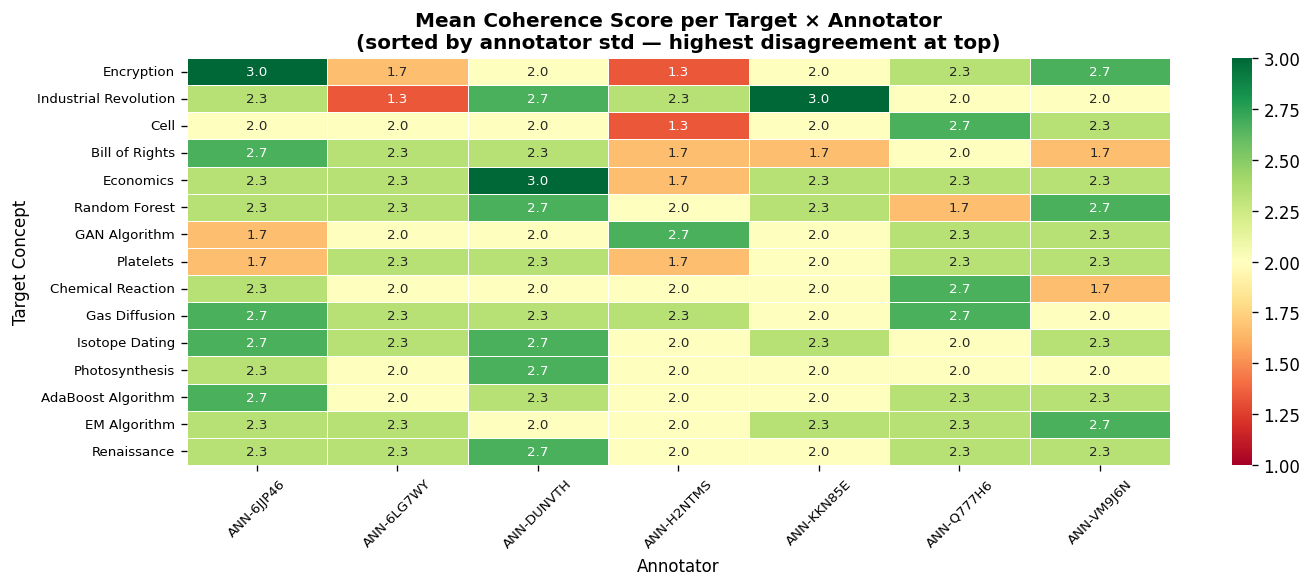

In [40]:
# ── Average score per (target, annotator) — coherence as representative ───────
target_ann_coh = (
    human_df.groupby(['target', 'annotator_id'])['coherence']
    .mean()
    .unstack('annotator_id')
)

# Add std across annotators
target_ann_coh['Std'] = target_ann_coh.std(axis=1)
target_order = target_ann_coh['Std'].sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    target_ann_coh.loc[target_order, annotators],
    annot=True, fmt='.1f', cmap='RdYlGn',
    vmin=1, vmax=3, linewidths=0.5, ax=ax, annot_kws={'size': 8}
)
ax.set_title('Mean Coherence Score per Target × Annotator\n(sorted by annotator std — highest disagreement at top)')
ax.set_xlabel('Annotator')
ax.set_ylabel('Target Concept')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, 'per_target_agreement_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Section 3 — Model Rankings from Human Annotations

In [61]:
# ── Merge human scores onto Excel file ───────────────────────────────────────
human_avg = (
    human_df.groupby(['target_key', 'analogy_key'])
    .agg(
        avg_coherence  = ('coherence',   'mean'),
        avg_mapping    = ('mapping',     'mean'),
        avg_explanatory= ('explanatory', 'mean'),
        avg_rank       = ('rank',        'mean'),
        n_annotators   = ('annotator_id','nunique'),
    )
    .reset_index()
)

xl_merged = xl.merge(human_avg, on=['target_key', 'analogy_key'], how='left')
xl_merged['avg_score_human'] = xl_merged[['avg_coherence','avg_mapping','avg_explanatory']].mean(axis=1)

print(f'Merged rows: {len(xl_merged)}')
xl_merged[['target','analogy','gen_model','gen_mode','quality_tier',
           'avg_coherence','avg_mapping','avg_explanatory','avg_rank']].round(2)

Merged rows: 45


,target,analogy,gen_model,gen_mode,quality_tier,avg_coherence,avg_mapping,avg_explanatory,avg_rank
0,Gas Diffusion,Perfume spreading,gpt-oss-120b,targetonly,HIGH,2.86,2.71,2.86,1.29
1,Gas Diffusion,Smoke dispersion,qwen3-14b,withsub,MIDDLE,2.71,2.43,2.43,1.71
2,Gas Diffusion,Gasoline,qwen3-14b,targetonly,LOW,1.43,1.43,1.14,3.00
3,Encryption,locked box,gpt-oss-120b,targetonly,HIGH,2.43,2.57,2.57,1.57
4,Encryption,Sealed envelope,grok-4-fast,withsub,MIDDLE,1.86,2.14,1.71,2.29
5,Encryption,Locker,gpt-4.1-nano,withsub,LOW,2.14,2.14,2.14,2.14
6,Industrial Revolution,Steam engine era,gpt-oss-120b,targetonly,HIGH,2.29,2.14,1.43,2.14
7,Industrial Revolution,Automation,meta-llama-3-1-8b-instruct,withsub,MIDDLE,2.14,2.14,1.86,2.14
8,Industrial Revolution,Industrialization,llama-3.1-405b-instruct,targetonly,LOW,2.29,2.71,2.00,1.71
9,GAN Algorithm,Art forgery,grok-4-fast,targetonly,HIGH,2.86,2.71,2.71,1.14


In [42]:
# ── Best-ranked analogies table ───────────────────────────────────────────────
best_analogy_per_target = (
    xl_merged.sort_values('avg_rank')
    .groupby('target')
    .first()
    .reset_index()
    [['target','analogy','gen_model','gen_mode','quality_tier',
      'avg_coherence','avg_mapping','avg_explanatory','avg_rank']]
    .round(2)
)
print('=== Top-Ranked Analogy per Target (by mean human rank) ===')
best_analogy_per_target

=== Top-Ranked Analogy per Target (by mean human rank) ===


,target,analogy,gen_model,gen_mode,quality_tier,avg_coherence,avg_mapping,avg_explanatory,avg_rank
0,AdaBoost Algorithm,Teamwork,gemini-2.5-flash-lite,withsub,HIGH,2.86,2.71,3.00,1.14
1,Bill of Rights,Rulebook,qwen3-32b,targetonly,HIGH,3.00,2.86,2.86,1.29
2,Chemical Reaction,Baking soda + vinegar,qwen3-14b,targetonly,HIGH,2.86,2.71,2.86,1.14
3,EM Algorithm,guess‑and‑check,gpt-oss-120b,withsub,MIDDLE,2.57,2.57,2.57,1.43
4,Economics,Marketplace,qwen3-14b,targetonly,HIGH,2.71,2.29,2.29,1.86
5,Encryption,locked box,gpt-oss-120b,targetonly,HIGH,2.43,2.57,2.57,1.57
6,GAN Algorithm,Art forgery,grok-4-fast,targetonly,HIGH,2.86,2.71,2.71,1.14
7,Gas Diffusion,Perfume spreading,gpt-oss-120b,targetonly,HIGH,2.86,2.71,2.86,1.29
8,Industrial Revolution,Industrialization,llama-3.1-405b-instruct,targetonly,LOW,2.29,2.71,2.00,1.71
9,Isotope Dating,Hourglass,deepseek-r1,withsub,HIGH,2.86,2.57,2.71,1.29


In [66]:
# ── Per-model average human scores ───────────────────────────────────────────
# Exclude retrieval-based baselines for LLM comparison
xl_llm = xl_merged[~xl_merged['gen_model'].str.contains('retrieval', na=True)].copy()

model_scores = (
    xl_llm.groupby(['target','analogy','gen_model','gen_mode'])
    .agg(
        Coherence   = ('avg_coherence',   'mean'),
        Mapping     = ('avg_mapping',     'mean'),
        Explanatory = ('avg_explanatory', 'mean'),
        Rank        = ('avg_rank',        'mean'),
        Count       = ('analogy',         'count'),
    )
    .reset_index()
    .round(3)
)

model_scores['Avg Score'] = model_scores[['Coherence','Mapping','Explanatory']].mean(axis=1).round(3)
print('=== Human Scores by Generator Model & Mode ===')
model_scores.sort_values('Avg Score', ascending=False)

=== Human Scores by Generator Model & Mode ===


,target,analogy,gen_model,gen_mode,Coherence,Mapping,Explanatory,Rank,Count,Avg Score
34,Platelets,Tiny repair crew,gemini-2.5-flash-lite,targetonly,3.000,3.000,3.000,1.000,1,3.000
4,Bill of Rights,Rulebook,qwen3-32b,targetonly,3.000,2.857,2.857,1.286,1,2.905
42,random forest,Voting committee,gemini-2.5-flash-lite,withsub,2.857,2.857,2.857,1.000,1,2.857
1,AdaBoost Algorithm,Teamwork,gemini-2.5-flash-lite,withsub,2.857,2.714,3.000,1.143,1,2.857
6,Chemical Reaction,Baking soda + vinegar,qwen3-14b,targetonly,2.857,2.714,2.857,1.143,1,2.809
21,Gas Diffusion,Perfume spreading,gpt-oss-120b,targetonly,2.857,2.714,2.857,1.286,1,2.809
17,GAN Algorithm,Art forgery,grok-4-fast,targetonly,2.857,2.714,2.714,1.143,1,2.762
28,Isotope Dating,Hourglass,deepseek-r1,withsub,2.857,2.571,2.714,1.286,1,2.714
9,EM Algorithm,Detective investigation,gpt-oss-120b,targetonly,2.714,2.714,2.714,1.571,1,2.714
31,Photosynthesis,Solar panels,llama-3.1-405b-instruct,withsub,2.857,2.571,2.571,1.286,1,2.666


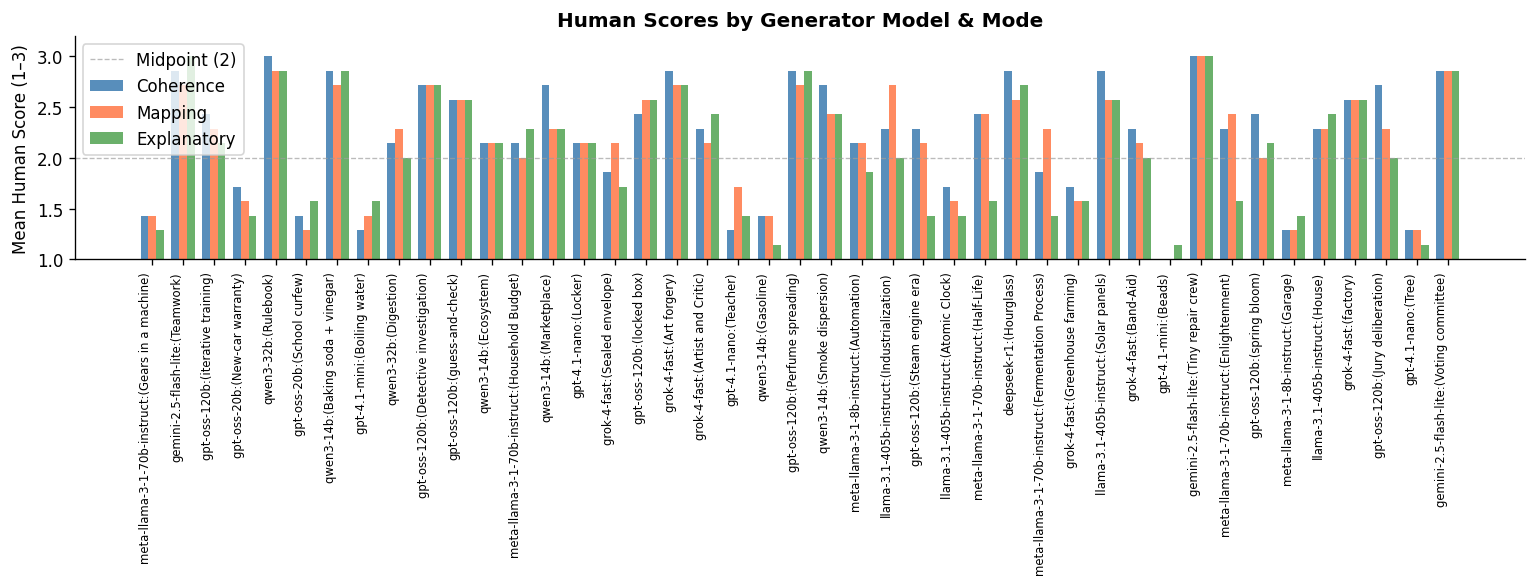

In [76]:
# ── Grouped bar chart: model scores by dimension ─────────────────────────────
pivot_model = model_scores.set_index(['gen_model','analogy'])[['Coherence','Mapping','Explanatory']]

fig, ax = plt.subplots(figsize=(13, 5))

x_labels = [f"{m}:({analogy})" for m, analogy in pivot_model.index]
x = np.arange(len(x_labels))
width = 0.25

for i, (dim, color) in enumerate(zip(['Coherence','Mapping','Explanatory'], [STEEL, CORAL, GREEN])):
    ax.bar(x + i*width, pivot_model[dim].values, width, label=dim, color=color, alpha=0.9)

ax.set_xticks(x + width)
ax.set_xticklabels(x_labels, fontsize=7, rotation=90, ha='right')
ax.set_ylabel('Mean Human Score (1–3)')
ax.set_ylim(1, 3.2)
ax.axhline(2, color=GRAY, linestyle='--', linewidth=0.8, alpha=0.7, label='Midpoint (2)')
ax.legend()
ax.set_title('Human Scores by Generator Model & Mode')
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, 'model_scores_human.png'), dpi=150, bbox_inches='tight')
plt.show()

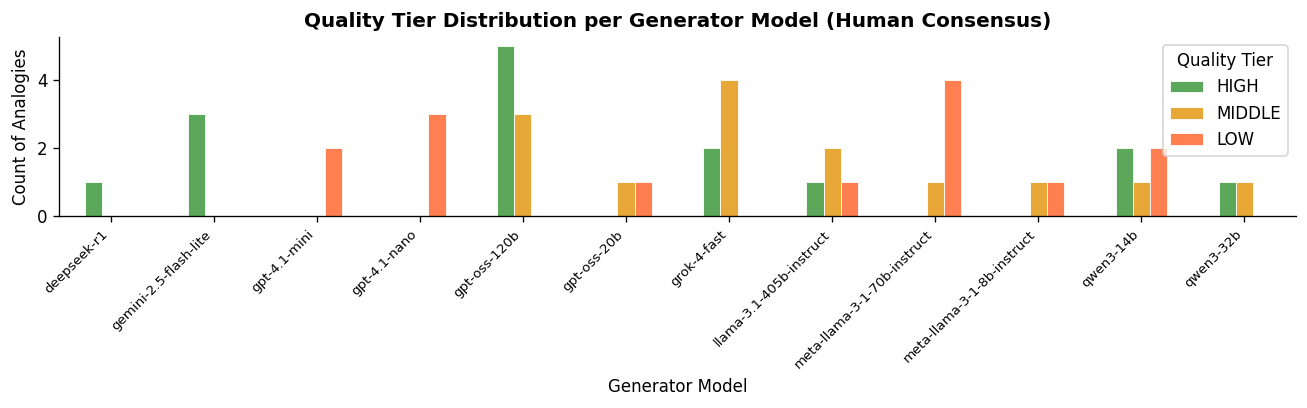

In [45]:
# ── Quality Tier breakdown ────────────────────────────────────────────────────
tier_model = (
    xl_llm.groupby(['quality_tier','gen_model'])
    .size()
    .unstack('gen_model', fill_value=0)
)

tier_order = ['HIGH', 'MIDDLE', 'LOW']
tier_model = tier_model.reindex([t for t in tier_order if t in tier_model.index])

fig, ax = plt.subplots(figsize=(11, 3.5))
tier_model.T.plot(kind='bar', ax=ax, color=[GREEN, AMBER, CORAL],
                  edgecolor='white', linewidth=0.5)
ax.set_xlabel('Generator Model')
ax.set_ylabel('Count of Analogies')
ax.set_title('Quality Tier Distribution per Generator Model (Human Consensus)')
ax.legend(title='Quality Tier', loc='upper right')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, 'quality_tier_by_model.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Section 4 — Claude vs Human Annotators

We filter the Claude CSV to the **45 specific analogies** that human annotators rated, then compare Claude's scores to each annotator's scores.

In [77]:
# ── Filter Claude CSV to the 45 human-annotated analogies ────────────────────
# Match on (target_key, analogy_key); pick first match per pair
# (Claude may have rated the same analogy from multiple model runs — use the correct model/mode)

# Build lookup keys from the Excel file (ground truth for which model generated which)
xl_keys = xl[['target_key','analogy_key','gen_model','gen_mode','analogy_type']].copy()
xl_keys.columns = ['target_key','analogy_key','xl_model','xl_mode','xl_type']

claude_sub = claude_df.merge(
    xl_keys,
    left_on =['target_key','analogy_key','model','original_mode','analogy_type'],
    right_on=['target_key','analogy_key','xl_model','xl_mode','xl_type'],
    how='inner'
)

if len(claude_sub) == 0:
    # Fallback: match on target + analogy only (ignore model/mode)
    print('Exact model/mode match yielded 0 rows → falling back to (target, analogy) match')
    claude_sub = (
        claude_df.merge(
            xl[['target_key','analogy_key']].drop_duplicates(),
            on=['target_key','analogy_key'],
            how='inner'
        )
        .sort_values('average_score', ascending=False)
        .drop_duplicates(['target_key','analogy_key'])
    )

print(f'Claude sub (matched): {len(claude_sub)} rows')

# Rename for clarity
claude_sub = claude_sub.rename(columns={
    'analogy_coherence': 'claude_coherence',
    'mapping_soundness': 'claude_mapping',
    'explanatory_power': 'claude_explanatory',
    'average_score'    : 'claude_avg',
})
claude_sub

Claude sub (matched): 45 rows


,target,model,original_mode,analogy_type,chosen_analogy,claude_coherence,claude_mapping,claude_explanatory,claude_avg,status,analogy_key,target_key,xl_model,xl_mode,xl_type
0,Platelets,gemini-2.5-flash-lite,targetonly,baseline,Tiny repair crew,3.0,2.0,2.0,2.3333,success,tiny repair crew,platelets,gemini-2.5-flash-lite,targetonly,baseline
1,Platelets,gpt-4.1-mini,targetonly,embedding,Beads,2.0,1.0,1.0,1.3333,success,beads,platelets,gpt-4.1-mini,targetonly,embedding
2,Chemical Reaction,gpt-4.1-mini,targetonly,embedding,Boiling water,1.0,1.0,1.0,1.0000,success,boiling water,chemical reaction,gpt-4.1-mini,targetonly,embedding
3,random forest,gpt-4.1-nano,targetonly,baseline,Tree,2.0,1.0,1.0,1.3333,success,tree,random forest,gpt-4.1-nano,targetonly,baseline
4,GAN Algorithm,gpt-4.1-nano,targetonly,baseline,Teacher,1.0,1.0,1.0,1.0000,success,teacher,gan algorithm,gpt-4.1-nano,targetonly,baseline
5,EM Algorithm,gpt-oss-120b,targetonly,baseline,Detective investigation,2.0,2.0,2.0,2.0000,success,detective investigation,em algorithm,gpt-oss-120b,targetonly,baseline
6,Industrial Revolution,gpt-oss-120b,targetonly,rerank,Steam engine era,1.0,1.0,1.0,1.0000,success,steam engine era,industrial revolution,gpt-oss-120b,targetonly,rerank
7,Renaissance,gpt-oss-120b,targetonly,baseline,spring bloom,3.0,2.0,2.0,2.3333,success,spring bloom,renaissance,gpt-oss-120b,targetonly,baseline
8,Gas Diffusion,gpt-oss-120b,targetonly,baseline,Perfume spreading,3.0,3.0,3.0,3.0000,success,perfume spreading,gas diffusion,gpt-oss-120b,targetonly,baseline
9,Bill of Rights,gpt-oss-20b,targetonly,baseline,School curfew,1.0,1.0,1.0,1.0000,success,school curfew,bill of rights,gpt-oss-20b,targetonly,baseline


In [99]:
# ── Merge human averages onto matched Claude rows ────────────────────────────
comparison_df = claude_sub.merge(
    human_avg.rename(columns={
        'avg_coherence'  : 'human_coherence',
        'avg_mapping'    : 'human_mapping',
        'avg_explanatory': 'human_explanatory',
        'avg_rank'       : 'human_rank',
    }),
    on=['target_key','analogy_key'],
    how='inner'
)

print(f'Comparison rows: {len(comparison_df)}')
comparison_df[['target','chosen_analogy','model','original_mode',
               'claude_coherence','claude_mapping','claude_explanatory',
               'human_coherence','human_mapping','human_explanatory']].round(2)

Comparison rows: 45


,target,chosen_analogy,model,original_mode,claude_coherence,claude_mapping,claude_explanatory,human_coherence,human_mapping,human_explanatory
0,Platelets,Tiny repair crew,gemini-2.5-flash-lite,targetonly,3.0,2.0,2.0,3.00,3.00,3.00
1,Platelets,Beads,gpt-4.1-mini,targetonly,2.0,1.0,1.0,1.00,1.00,1.14
2,Chemical Reaction,Boiling water,gpt-4.1-mini,targetonly,1.0,1.0,1.0,1.29,1.43,1.57
3,random forest,Tree,gpt-4.1-nano,targetonly,2.0,1.0,1.0,1.29,1.29,1.14
4,GAN Algorithm,Teacher,gpt-4.1-nano,targetonly,1.0,1.0,1.0,1.29,1.71,1.43
5,EM Algorithm,Detective investigation,gpt-oss-120b,targetonly,2.0,2.0,2.0,2.71,2.71,2.71
6,Industrial Revolution,Steam engine era,gpt-oss-120b,targetonly,1.0,1.0,1.0,2.29,2.14,1.43
7,Renaissance,spring bloom,gpt-oss-120b,targetonly,3.0,2.0,2.0,2.43,2.00,2.14
8,Gas Diffusion,Perfume spreading,gpt-oss-120b,targetonly,3.0,3.0,3.0,2.86,2.71,2.86
9,Bill of Rights,School curfew,gpt-oss-20b,targetonly,1.0,1.0,1.0,1.43,1.29,1.57


In [88]:
# ── Correlation: Claude vs each annotator per dimension ───────────────────────
corr_claude_ann = {}
for dim, cdim in zip(DIMS, ['claude_coherence','claude_mapping','claude_explanatory']):
    dim_corrs = {}
    for ann in annotators:
        ann_data = human_df[human_df['annotator_id'] == ann][['target_key','analogy_key', dim]]
        merged_ann = comparison_df.merge(ann_data, on=['target_key','analogy_key'], how='inner',
                                         suffixes=('_claude','_ann'))
        if len(merged_ann) > 3:
            rho, _ = stats.spearmanr(merged_ann[cdim], merged_ann[dim])
            dim_corrs[ann] = rho
        else:
            dim_corrs[ann] = np.nan
    corr_claude_ann[dim] = dim_corrs

corr_claude_df = pd.DataFrame(corr_claude_ann).T
corr_claude_df.index.name = 'Dimension'
print('=== Spearman ρ: Claude vs each annotator ===')
corr_claude_df

=== Spearman ρ: Claude vs each annotator ===


,ANN-6JJP46,ANN-6LG7WY,ANN-DUNVTH,ANN-H2NTMS,ANN-KKN85E,ANN-Q777H6,ANN-VM9J6N
Dimension,,,,,,,
coherence,0.375714,0.581326,0.349420,0.249684,0.315580,0.129739,0.575716
mapping,0.225097,0.507025,0.278012,0.334456,0.450405,0.124477,0.476341
explanatory,0.417181,0.672197,0.370907,0.553595,0.521689,0.269149,0.677955


In [108]:
# ── Derive Claude's implicit rank per target ──────────────────────────────────
comparison_df['claude_rank'] = (
    comparison_df.groupby('target_key')['claude_avg']
    .rank(ascending=False, method='min')
    .astype(int)
)

# ── Spearman ρ: Claude rank vs each annotator's rank ─────────────────────────
rank_corrs = {}
for ann in annotators:
    ann_data = human_df[human_df['annotator_id'] == ann][['target_key', 'analogy_key', 'rank']]
    merged = comparison_df[['target_key', 'analogy_key', 'claude_rank']].merge(
        ann_data, on=['target_key', 'analogy_key'], how='inner'
    )
    if len(merged) > 3:
        rho, p = stats.spearmanr(merged['claude_rank'], merged['rank'])
        rank_corrs[ann] = {'ρ': round(rho, 3), 'p': round(p, 4)}
    else:
        rank_corrs[ann] = {'ρ': np.nan, 'p': np.nan}

rank_corr_df = pd.DataFrame(rank_corrs).T
rank_corr_df.index.name = 'Annotator'
rank_corr_df['Significant'] = rank_corr_df['p'] < 0.05
print('=== Spearman ρ: Claude implicit rank vs human rank ===')
rank_corr_df


=== Spearman ρ: Claude implicit rank vs human rank ===


,ρ,p,Significant
Annotator,,,
ANN-6JJP46,0.474,0.0010,True
ANN-6LG7WY,0.705,0.0000,True
ANN-DUNVTH,0.307,0.0404,True
ANN-H2NTMS,0.694,0.0000,True
ANN-KKN85E,0.463,0.0014,True
ANN-Q777H6,0.128,0.4012,False
ANN-VM9J6N,0.694,0.0000,True


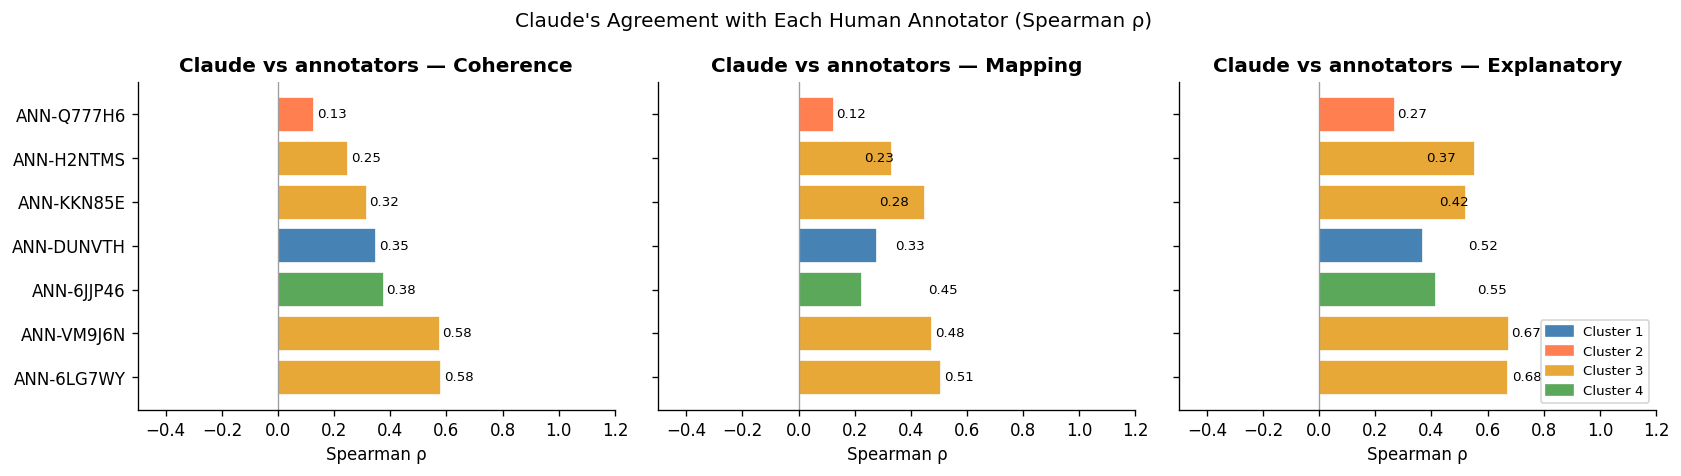

In [89]:
# ── Bar plot: Claude correlation with annotators ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, dim, label in zip(axes, DIMS, DIM_LABELS):
    vals = corr_claude_df.loc[dim].sort_values(ascending=False)
    bar_cols = [CLUSTER_COLORS[ann_to_cluster.get(a, 1) - 1] for a in vals.index]
    ax.barh(vals.index, vals.values, color=bar_cols, edgecolor='white')
    ax.axvline(0, color=GRAY, linewidth=0.8)
    for i, (ann, v) in enumerate(vals.items()):
        ax.text(v + 0.01 if v >= 0 else v - 0.01, i,
                f'{v:.2f}', va='center', ha='left' if v >= 0 else 'right', fontsize=8)
    ax.set_title(f'Claude vs annotators — {label}')
    ax.set_xlabel('Spearman ρ')
    ax.set_xlim(-0.5, 1.2)

# Cluster legend
legend_patches = [mpatches.Patch(color=CLUSTER_COLORS[i], label=f'Cluster {i+1}')
                  for i in range(best_k)]
axes[-1].legend(handles=legend_patches, loc='lower right', fontsize=8)

fig.suptitle("Claude's Agreement with Each Human Annotator (Spearman ρ)", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, 'claude_vs_annotators_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()

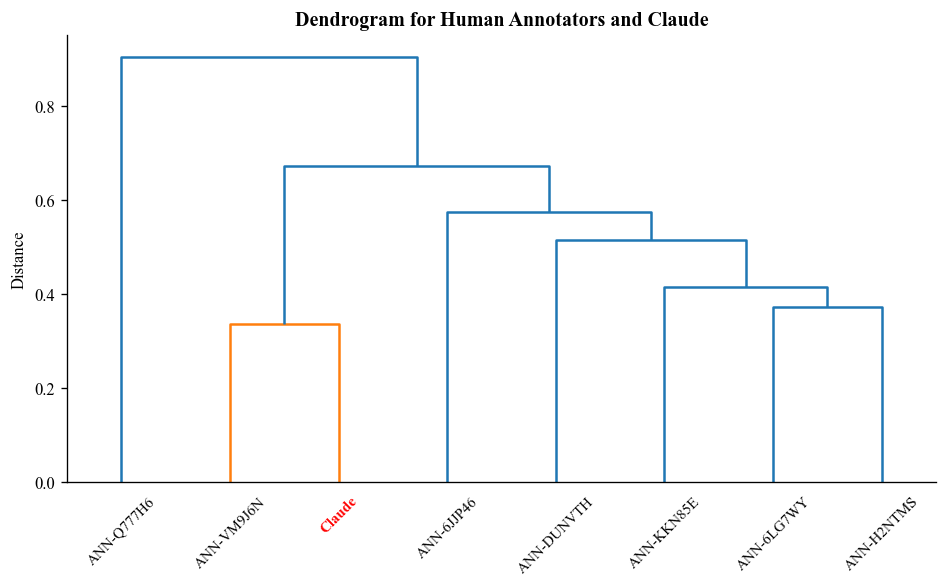

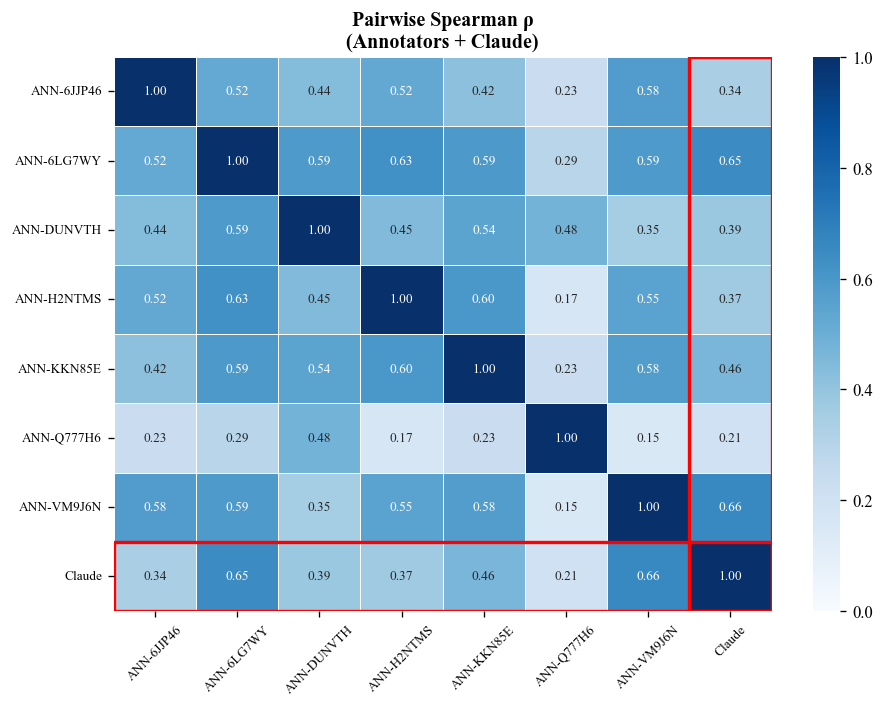


Claude is in Cluster 1 alongside: ['ANN-VM9J6N']


In [116]:
# ── Add Claude as the 8th 'annotator' in the clustering ──────────────────────
all_agents = annotators + ['Claude']

# Build per-analogy score vectors for all agents
score_vectors = {}
for ann in annotators:
    ann_sub = human_df[human_df['annotator_id'] == ann][['item_key'] + DIMS].set_index('item_key')
    score_vectors[ann] = ann_sub.mean(axis=1)

claude_item = comparison_df.copy()
claude_item['item_key'] = claude_item['target_key'] + ' | ' + claude_item['analogy_key']
claude_item = claude_item.set_index('item_key')['claude_avg']
score_vectors['Claude'] = claude_item

# Build 8×8 correlation matrix
n8 = len(all_agents)
corr_8 = np.eye(n8)
for i, a in enumerate(all_agents):
    for j, b in enumerate(all_agents):
        if i >= j:
            continue
        common = score_vectors[a].index.intersection(score_vectors[b].index)
        if len(common) > 3:
            rho, _ = stats.spearmanr(score_vectors[a][common], score_vectors[b][common])
            corr_8[i, j] = corr_8[j, i] = rho

corr_8_df = pd.DataFrame(corr_8, index=all_agents, columns=all_agents)

dist_8 = np.clip(1 - corr_8, 0, None)
np.fill_diagonal(dist_8, 0)
link_8 = linkage(squareform(dist_8), method='ward')

# ── Figure 1: Dendrogram ──────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(8, 5))
dend8 = dendrogram(link_8, labels=all_agents, ax=ax1,
                   color_threshold=0.4 * link_8[-1, 2],
                   leaf_font_size=9)
for lbl in ax1.get_xticklabels():
    if lbl.get_text() == 'Claude':
        lbl.set_color('red')
        lbl.set_weight('bold')
ax1.set_title('Dendrogram for Human Annotators and Claude')
ax1.set_ylabel('Distance')
ax1.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, 'annotators_plus_claude_dendrogram.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: Heatmap ─────────────────────────────────────────────────────────
fig, ax2 = plt.subplots(figsize=(8, 6))
cmap = sns.color_palette('Blues', as_cmap=True)
sns.heatmap(corr_8_df, annot=True, fmt='.2f', cmap=cmap,
            vmin=0, vmax=1, linewidths=0.5, ax=ax2, annot_kws={'size': 8})
ax2.set_title('Pairwise Spearman ρ\n(Annotators + Claude)')
ax2.tick_params(axis='x', rotation=45, labelsize=8)
ax2.tick_params(axis='y', rotation=0, labelsize=8)
claude_idx = all_agents.index('Claude')
ax2.add_patch(plt.Rectangle((claude_idx, 0), 1, n8, fill=False, edgecolor='red', lw=2))
ax2.add_patch(plt.Rectangle((0, claude_idx), n8, 1, fill=False, edgecolor='red', lw=2))
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, 'annotators_plus_claude_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

# Cluster labels
labels_8 = fcluster(link_8, best_k, criterion='maxclust')
agent_clusters = dict(zip(all_agents, labels_8))
claude_cluster = agent_clusters['Claude']
cluster_mates = [a for a, c in agent_clusters.items() if c == claude_cluster and a != 'Claude']
print(f'\nClaude is in Cluster {claude_cluster} alongside: {cluster_mates}')


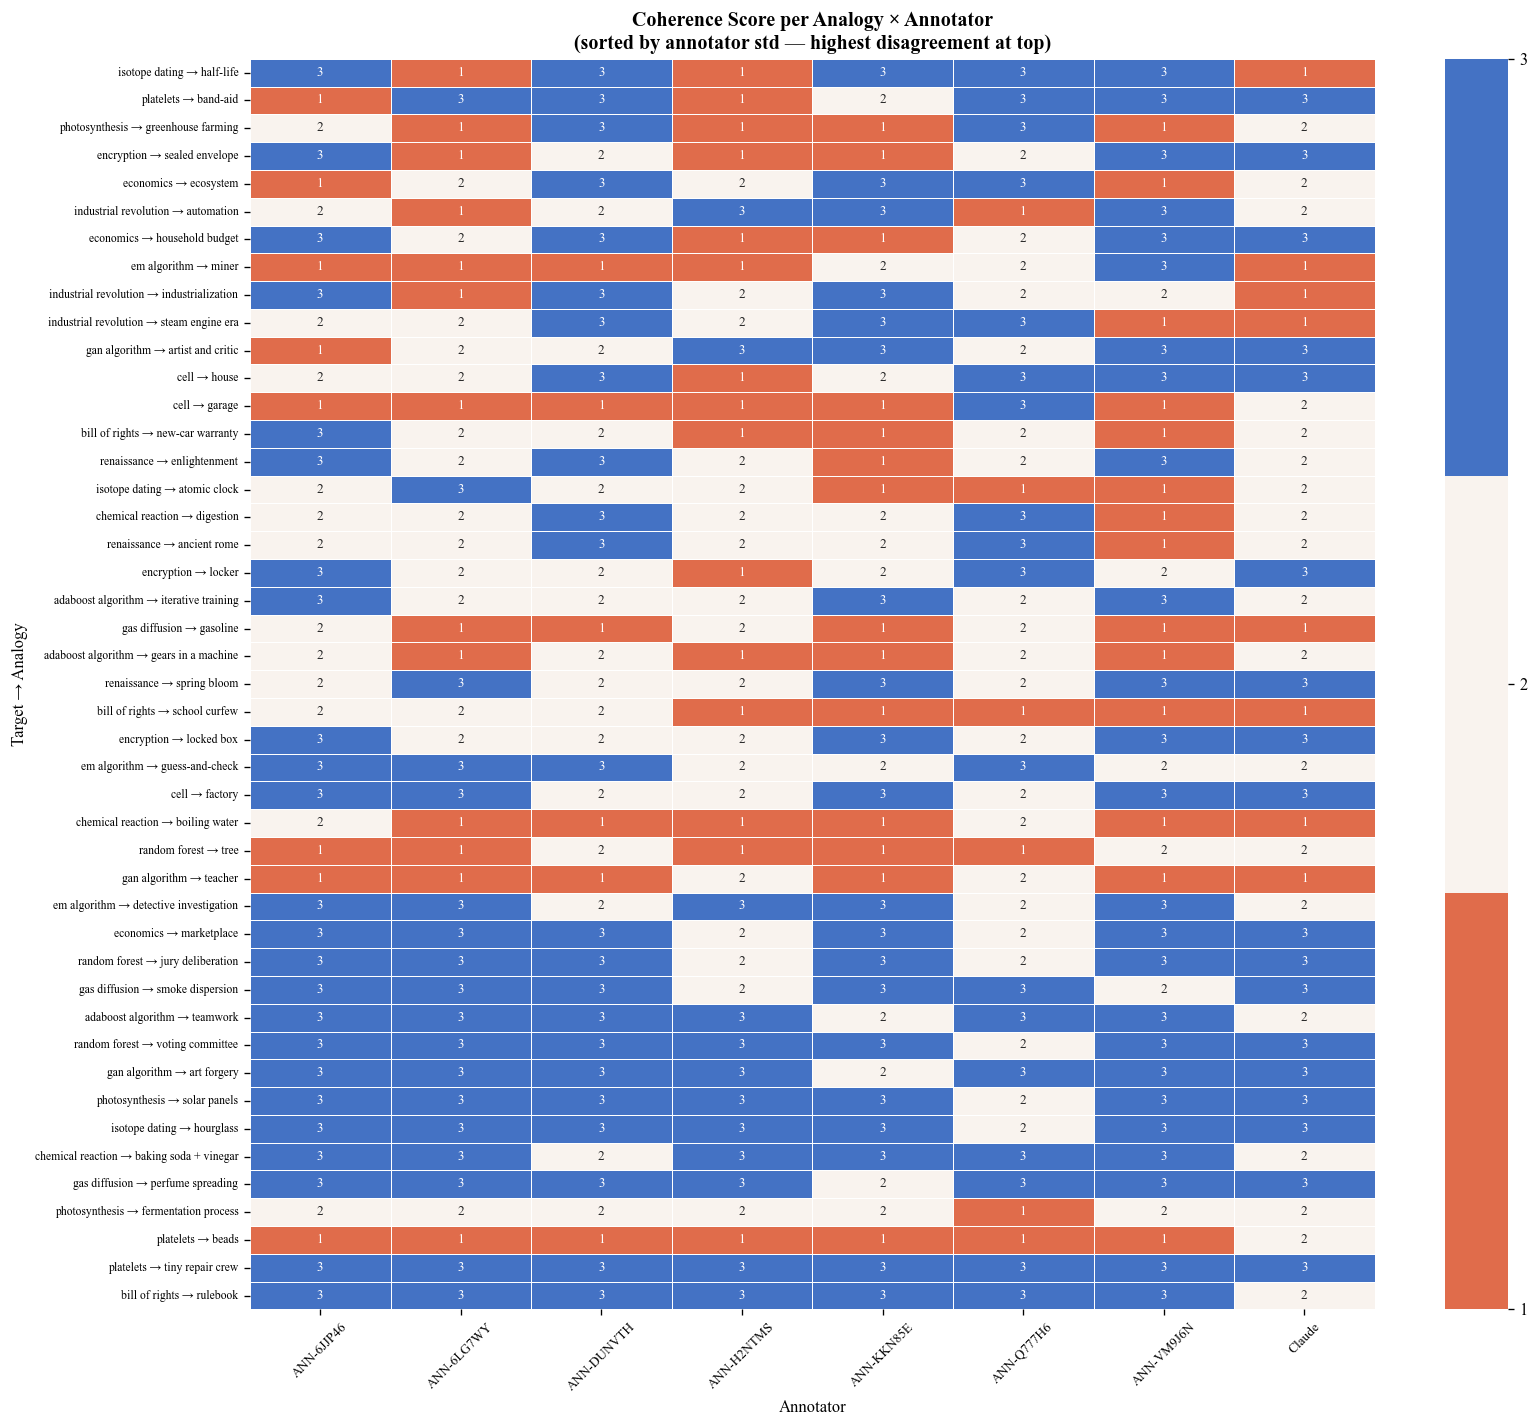

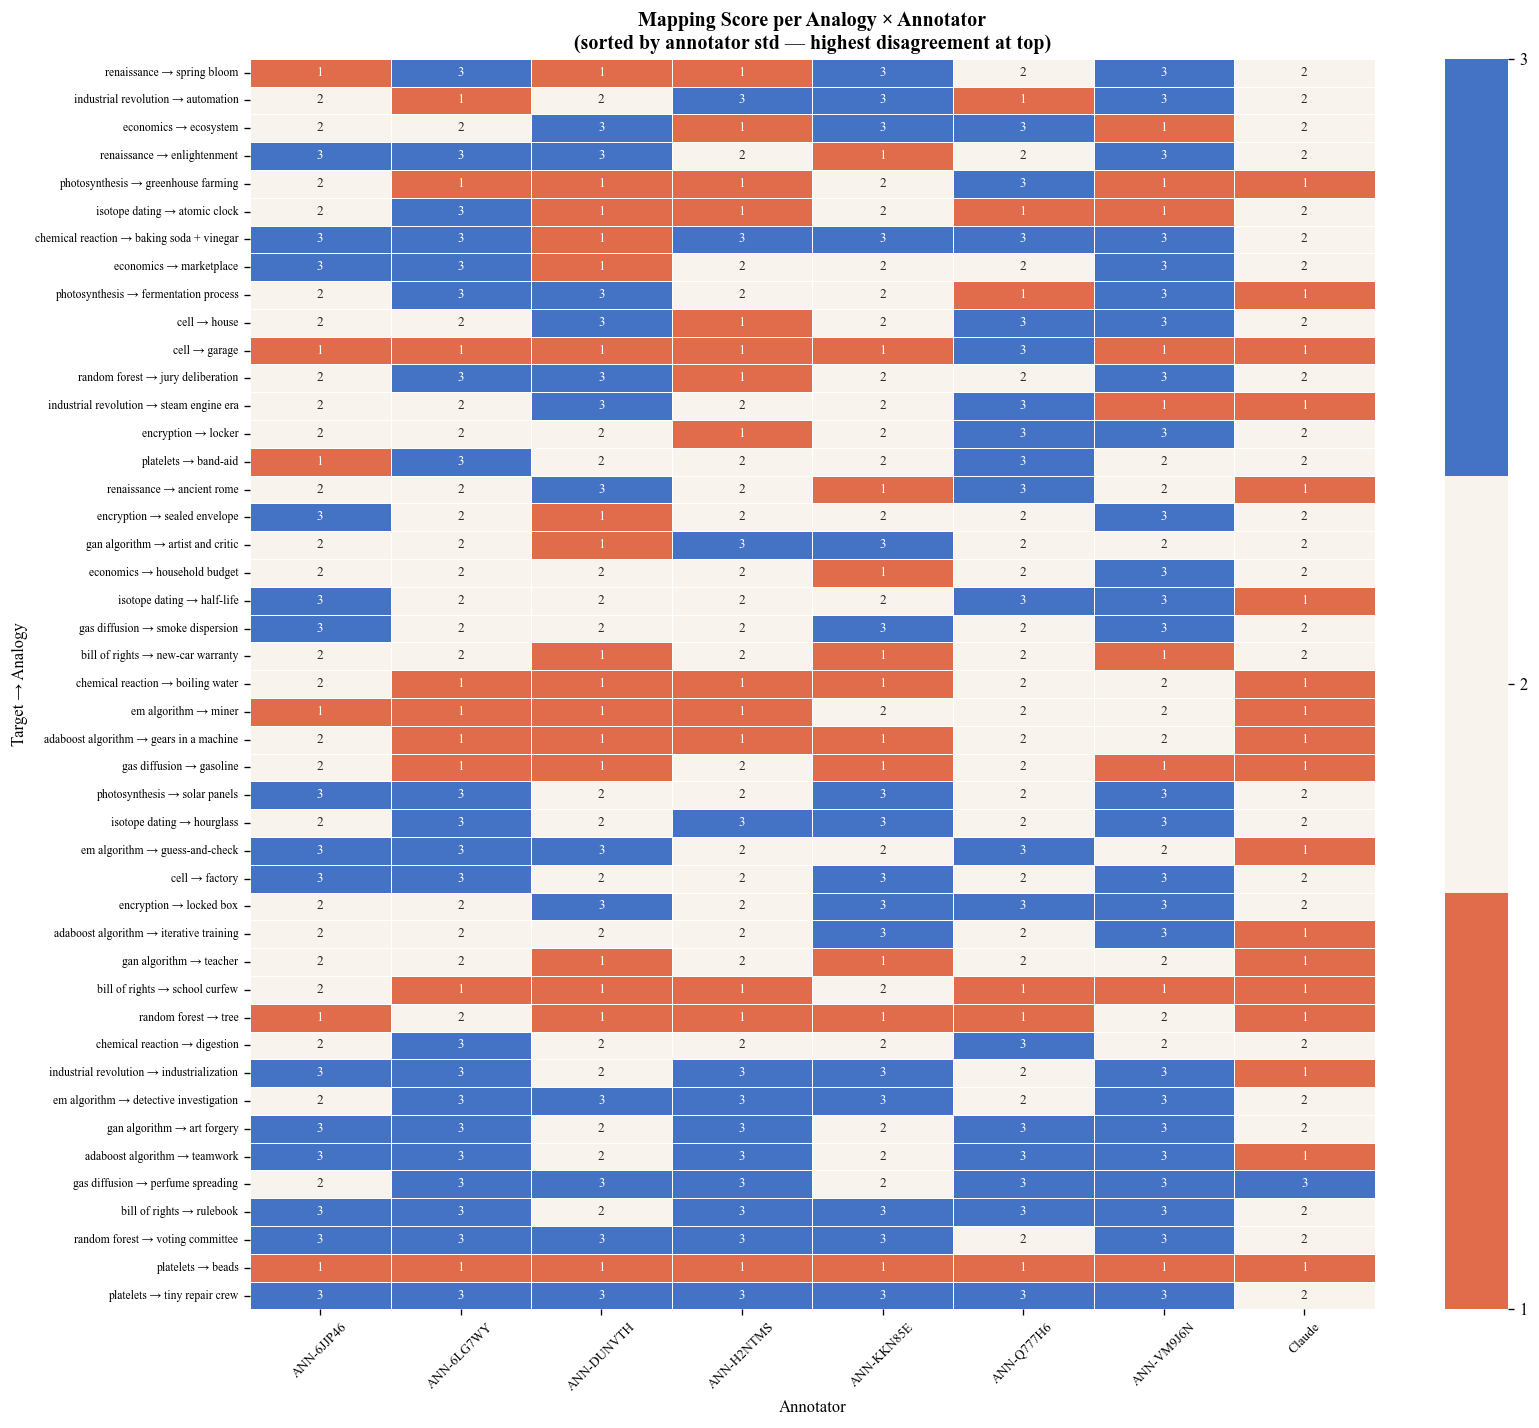

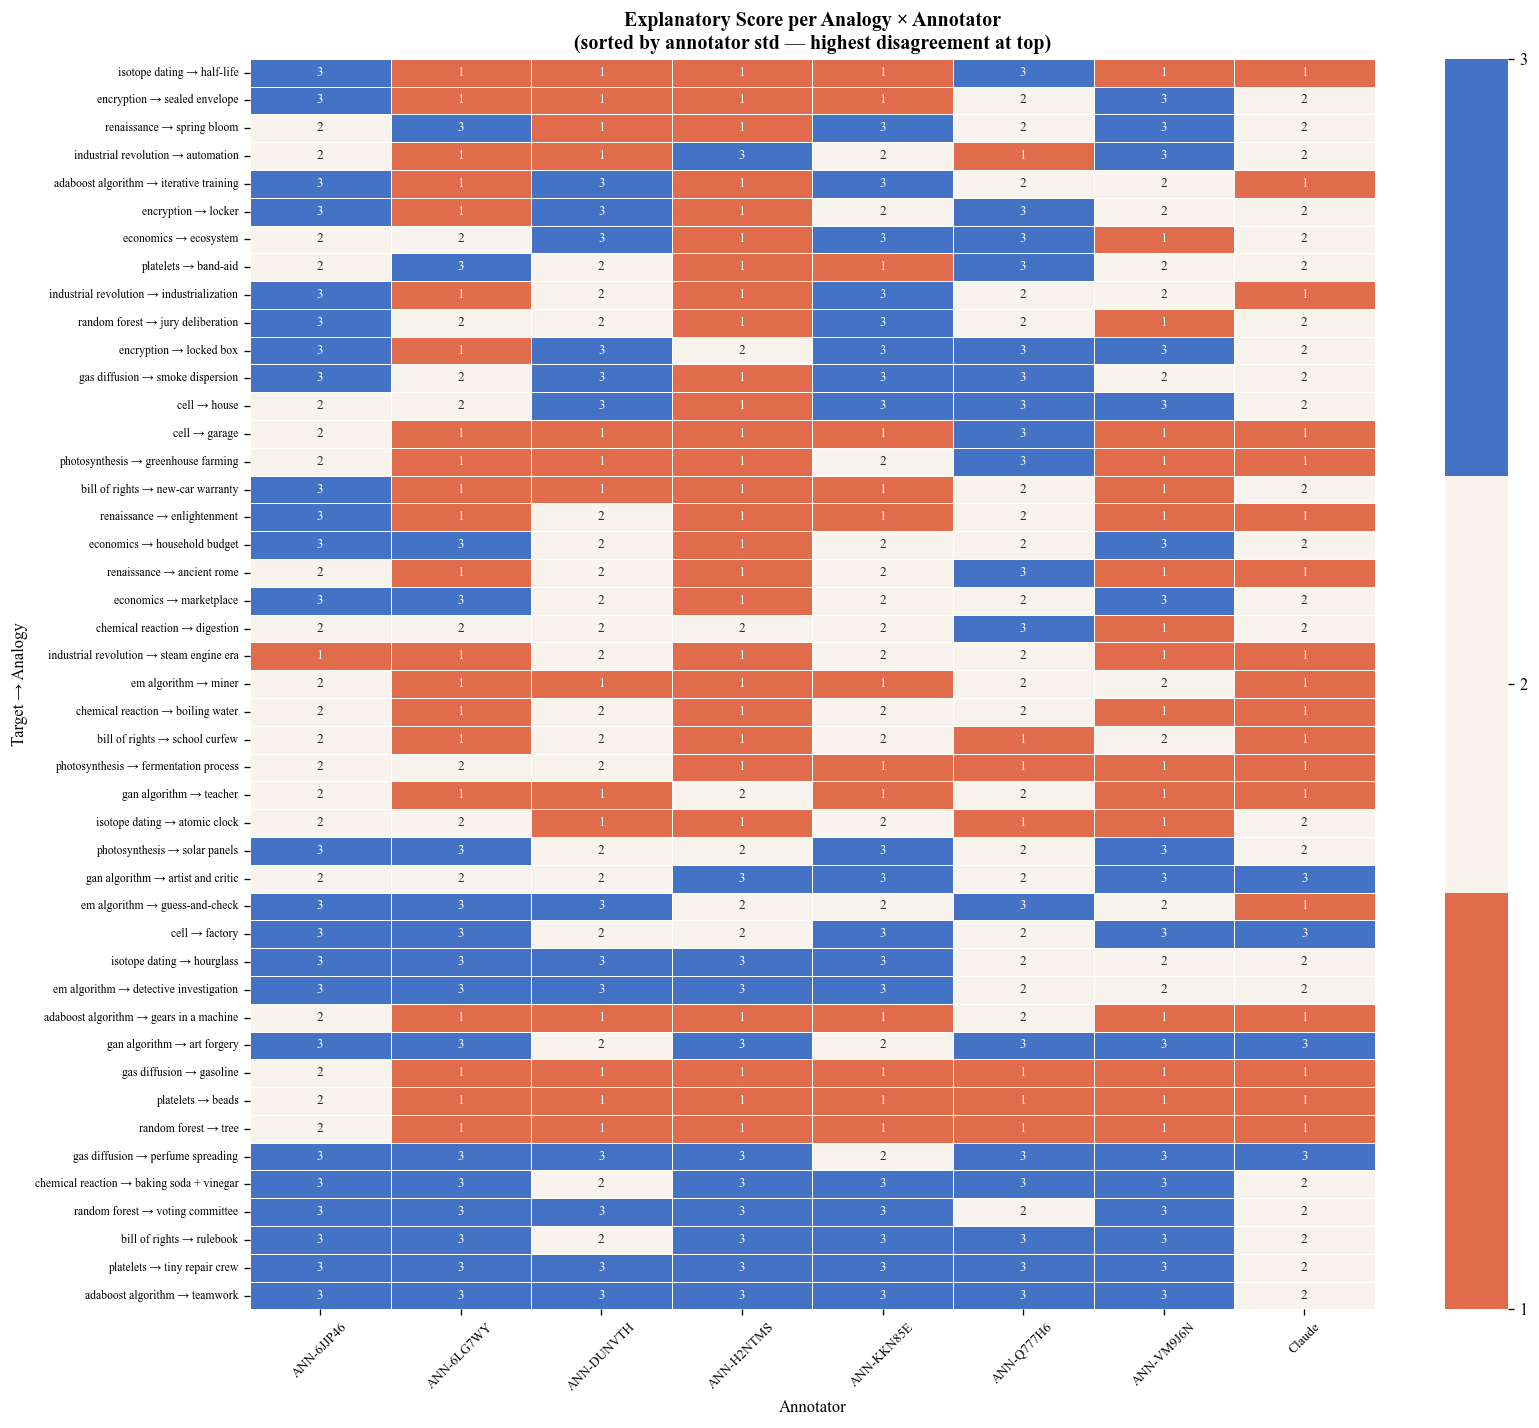

In [114]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib
matplotlib.rcParams['font.family'] = 'Times New Roman'

_cmap3 = LinearSegmentedColormap.from_list('ryg', ['#E06C4B', '#F9F3EE', '#4472C4'], N=3)

# ── Shared: build pair label ──────────────────────────────────────────────────
human_df['pair'] = human_df['target_key'] + ' → ' + human_df['analogy_key']
comparison_df['pair'] = comparison_df['target_key'] + ' → ' + comparison_df['analogy_key']

# ── Coherence ─────────────────────────────────────────────────────────────────
target_ann_coh = (
    human_df.groupby(['pair', 'annotator_id'])['coherence']
    .mean().unstack('annotator_id')
)
target_ann_coh['Claude'] = comparison_df.groupby('pair')['claude_coherence'].mean()
target_ann_coh['Std'] = target_ann_coh[annotators].std(axis=1)
target_order = target_ann_coh['Std'].sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    target_ann_coh.loc[target_order, annotators + ['Claude']],
    annot=True, fmt='.0f', cmap=_cmap3, vmin=1, vmax=3,
    linewidths=0.5, ax=ax, annot_kws={'size': 8}
)
ax.collections[0].colorbar.set_ticks([1, 2, 3])
ax.collections[0].colorbar.set_ticklabels(['1', '2', '3'])
ax.set_title('Coherence Score per Analogy × Annotator\n(sorted by annotator std — highest disagreement at top)')
ax.set_xlabel('Annotator')
ax.set_ylabel('Target → Analogy')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=7)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, 'per_target_agreement_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Mapping ───────────────────────────────────────────────────────────────────
target_ann_map = (
    human_df.groupby(['pair', 'annotator_id'])['mapping']
    .mean().unstack('annotator_id')
)
target_ann_map['Claude'] = comparison_df.groupby('pair')['claude_mapping'].mean()
target_ann_map['Std'] = target_ann_map[annotators].std(axis=1)
target_order_map = target_ann_map['Std'].sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    target_ann_map.loc[target_order_map, annotators + ['Claude']],
    annot=True, fmt='.0f', cmap=_cmap3, vmin=1, vmax=3,
    linewidths=0.5, ax=ax, annot_kws={'size': 8}
)
ax.collections[0].colorbar.set_ticks([1, 2, 3])
ax.collections[0].colorbar.set_ticklabels(['1', '2', '3'])
ax.set_title('Mapping Score per Analogy × Annotator\n(sorted by annotator std — highest disagreement at top)')
ax.set_xlabel('Annotator')
ax.set_ylabel('Target → Analogy')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=7)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, 'per_target_agreement_heatmap_mapping.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Explanatory ───────────────────────────────────────────────────────────────
target_ann_exp = (
    human_df.groupby(['pair', 'annotator_id'])['explanatory']
    .mean().unstack('annotator_id')
)
target_ann_exp['Claude'] = comparison_df.groupby('pair')['claude_explanatory'].mean()
target_ann_exp['Std'] = target_ann_exp[annotators].std(axis=1)
target_order_exp = target_ann_exp['Std'].sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    target_ann_exp.loc[target_order_exp, annotators + ['Claude']],
    annot=True, fmt='.0f', cmap=_cmap3, vmin=1, vmax=3,
    linewidths=0.5, ax=ax, annot_kws={'size': 8}
)
ax.collections[0].colorbar.set_ticks([1, 2, 3])
ax.collections[0].colorbar.set_ticklabels(['1', '2', '3'])
ax.set_title('Explanatory Score per Analogy × Annotator\n(sorted by annotator std — highest disagreement at top)')
ax.set_xlabel('Annotator')
ax.set_ylabel('Target → Analogy')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=7)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, 'per_target_agreement_heatmap_explanatory.png'), dpi=150, bbox_inches='tight')
plt.show()


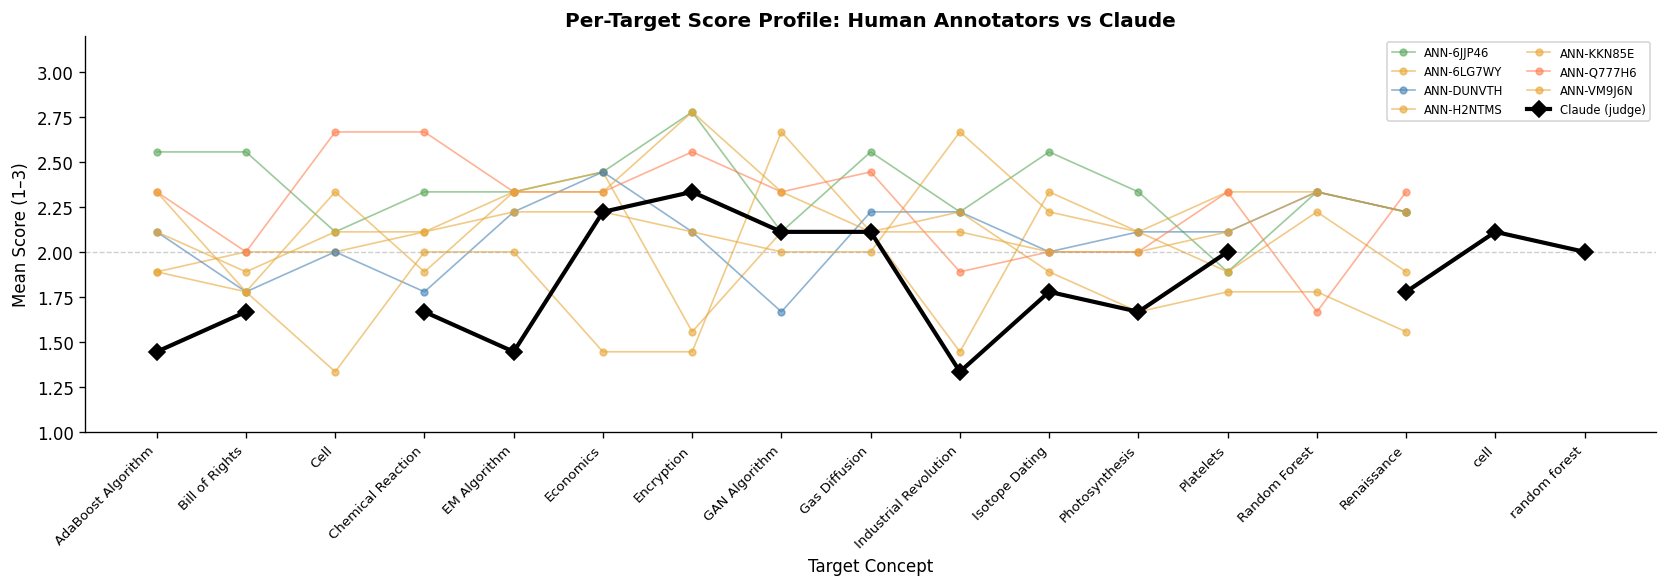

In [91]:
# ── Side-by-side score profiles: annotators + Claude per target ───────────────
# Show avg score across all 3 analogies of each target for each agent

human_per_target = (
    human_df.groupby(['target', 'annotator_id'])
    [DIMS].mean().mean(axis=1)  # average across dimensions
    .reset_index().rename(columns={0: 'avg_score'})
)
human_per_target = human_per_target.pivot(index='target', columns='annotator_id', values='avg_score')

claude_per_target = (
    comparison_df.groupby('target')
    [['claude_coherence','claude_mapping','claude_explanatory']].mean().mean(axis=1)
    .rename('Claude')
)

profile_wide = human_per_target.join(claude_per_target, how='outer')

fig, ax = plt.subplots(figsize=(14, 5))
for i, ann in enumerate(annotators):
    color = CLUSTER_COLORS[ann_to_cluster.get(ann, 1) - 1]
    ax.plot(profile_wide.index, profile_wide[ann], marker='o', markersize=4,
            color=color, alpha=0.6, linewidth=1, label=ann)

# Claude with bold style
ax.plot(profile_wide.index, profile_wide['Claude'], marker='D', markersize=7,
        color='black', linewidth=2.5, label='Claude (judge)', zorder=10)

ax.set_ylabel('Mean Score (1–3)')
ax.set_xlabel('Target Concept')
ax.set_title('Per-Target Score Profile: Human Annotators vs Claude')
ax.set_ylim(1, 3.2)
ax.axhline(2, color=GRAY, linestyle='--', linewidth=0.8, alpha=0.5)
plt.xticks(rotation=45, ha='right', fontsize=8)
ax.legend(loc='upper right', fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, 'per_target_profile_human_vs_claude.png'), dpi=150, bbox_inches='tight')
plt.show()

In [93]:
# ── Model & mode breakdown for the 45 analogies: annotators vs Claude ────────
# For each analogy show: model | mode | human_avg | claude_avg
summary_45 = comparison_df[[ 
    'target_key', 'analogy_key',       
    'target','chosen_analogy','model','original_mode',
    'claude_coherence','claude_mapping','claude_explanatory','claude_avg',
    'human_coherence','human_mapping','human_explanatory','human_rank'
]].copy()
summary_45 = summary_45.merge(
    xl[['target_key','analogy_key','quality_tier','agreement_level']],
    left_on=['target_key','analogy_key'], right_on=['target_key','analogy_key'],
    how='left'
) if 'target_key' in comparison_df.columns else summary_45

print('=== 45 Analogies: Human vs Claude Scores ===')
summary_45.round(2)

=== 45 Analogies: Human vs Claude Scores ===


,target_key,analogy_key,target,chosen_analogy,model,original_mode,claude_coherence,claude_mapping,claude_explanatory,claude_avg,human_coherence,human_mapping,human_explanatory,human_rank,quality_tier,agreement_level
0,platelets,tiny repair crew,Platelets,Tiny repair crew,gemini-2.5-flash-lite,targetonly,3.0,2.0,2.0,2.33,3.00,3.00,3.00,1.00,HIGH,GPT-Gemini
1,platelets,beads,Platelets,Beads,gpt-4.1-mini,targetonly,2.0,1.0,1.0,1.33,1.00,1.00,1.14,3.00,LOW,GPT-Gemini
2,chemical reaction,boiling water,Chemical Reaction,Boiling water,gpt-4.1-mini,targetonly,1.0,1.0,1.0,1.00,1.29,1.43,1.57,3.00,LOW,GPT-DeepSeek
3,random forest,tree,random forest,Tree,gpt-4.1-nano,targetonly,2.0,1.0,1.0,1.33,1.29,1.29,1.14,3.00,LOW,GPT-DeepSeek
4,gan algorithm,teacher,GAN Algorithm,Teacher,gpt-4.1-nano,targetonly,1.0,1.0,1.0,1.00,1.29,1.71,1.43,3.00,LOW,None Agree
5,em algorithm,detective investigation,EM Algorithm,Detective investigation,gpt-oss-120b,targetonly,2.0,2.0,2.0,2.00,2.71,2.71,2.71,1.57,HIGH,Gemini-DeepSeek
6,industrial revolution,steam engine era,Industrial Revolution,Steam engine era,gpt-oss-120b,targetonly,1.0,1.0,1.0,1.00,2.29,2.14,1.43,2.14,HIGH,All Agree
7,renaissance,spring bloom,Renaissance,spring bloom,gpt-oss-120b,targetonly,3.0,2.0,2.0,2.33,2.43,2.00,2.14,2.14,HIGH,Gemini-DeepSeek
8,gas diffusion,perfume spreading,Gas Diffusion,Perfume spreading,gpt-oss-120b,targetonly,3.0,3.0,3.0,3.00,2.86,2.71,2.86,1.29,HIGH,All Agree
9,bill of rights,school curfew,Bill of Rights,School curfew,gpt-oss-20b,targetonly,1.0,1.0,1.0,1.00,1.43,1.29,1.57,2.29,LOW,None Agree


In [94]:
# ── Rank agreement: Claude implied rank vs human consensus rank ───────────────
from scipy.stats import kendalltau

# Claude's implied rank per target: rank 1 = highest score
comparison_df['claude_rank'] = (
    comparison_df.groupby('target')['claude_avg']
    .rank(ascending=False, method='min')
)

tau_vals = []
for tgt in comparison_df['target'].unique():
    sub = comparison_df[comparison_df['target'] == tgt].copy()
    if len(sub) == 3:
        tau, p = kendalltau(sub['claude_rank'], sub['human_rank'])
        tau_vals.append({'target': tgt, 'kendall_tau': tau, 'p_value': p,
                         'claude_tied': sub['claude_avg'].nunique() == 1})

tau_df = pd.DataFrame(tau_vals).round(3)
mean_tau = tau_df['kendall_tau'].dropna().mean()
n_agree  = (tau_df['kendall_tau'].dropna() > 0).sum()
n_valid  = tau_df['kendall_tau'].notna().sum()
n_tied   = tau_df['kendall_tau'].isna().sum()
print(f'Mean Kendall τ (Claude vs Human rank): {mean_tau:.3f}  ({n_valid} non-tied targets)')
print(f'Targets with τ > 0 (agreement): {n_agree} / {n_valid}')
if n_tied > 0:
    tied_targets = tau_df[tau_df['kendall_tau'].isna()]['target'].tolist()
    print(f'Note: {n_tied} target(s) had all-tied Claude scores (τ undefined): {tied_targets}')
tau_df

Mean Kendall τ (Claude vs Human rank): 0.550  (14 non-tied targets)
Targets with τ > 0 (agreement): 11 / 14
Note: 1 target(s) had all-tied Claude scores (τ undefined): ['Encryption']


,target,kendall_tau,p_value,claude_tied
0,Platelets,0.816,0.221,False
1,Chemical Reaction,0.816,0.221,False
2,random forest,0.816,0.221,False
3,GAN Algorithm,0.816,0.221,False
4,EM Algorithm,0.333,1.000,False
5,Industrial Revolution,-0.500,0.480,False
6,Renaissance,0.000,1.000,False
7,Gas Diffusion,1.000,0.333,False
8,Bill of Rights,0.000,1.000,False
9,Photosynthesis,0.816,0.221,False


---
## Section 5 — Claude Model Comparison (Full Dataset)

Using all ~65K evaluated analogies to compare generator models across the three quality dimensions.

In [ ]:
# ── Exclude retrieval-based models for LLM comparison ─────────────────────────
llm_claude = claude_df[~claude_df['model'].str.contains('retrieval', na=True)].copy()
print(f'LLM rows: {len(llm_claude)} | Models: {sorted(llm_claude["model"].unique())}')

LLM rows: 22755 | Models: ['deepseek-r1', 'gemini-2.5-flash-lite', 'gpt-4.1-mini', 'gpt-4.1-nano', 'gpt-oss-120b', 'gpt-oss-20b', 'grok-4-fast', 'llama-3.1-405b-instruct', 'meta-llama-3-1-70b-instruct', 'meta-llama-3-1-8b-instruct', 'qwen3-14b', 'qwen3-32b']


In [ ]:
# ── 5A: Average scores by model (all modes combined) ─────────────────────────
model_agg = (
    llm_claude.groupby('model')
    .agg(
        Coherence   = ('analogy_coherence', 'mean'),
        Mapping     = ('mapping_soundness',  'mean'),
        Explanatory = ('explanatory_power',  'mean'),
        Overall     = ('average_score',      'mean'),
        N           = ('average_score',      'count'),
    )
    .reset_index()
    .sort_values('Overall', ascending=False)
    .round(3)
)

print('=== Claude Leaderboard (all modes & types) ===')
model_agg

=== Claude Leaderboard (all modes & types) ===


,model,Coherence,Mapping,Explanatory,Overall,N
0,deepseek-r1,2.493,1.898,1.951,2.114,1924
6,grok-4-fast,2.497,1.899,1.908,2.101,1926
4,gpt-oss-120b,2.403,1.838,1.866,2.036,1907
7,llama-3.1-405b-instruct,2.355,1.831,1.800,1.995,1926
8,meta-llama-3-1-70b-instruct,2.284,1.794,1.760,1.946,1924
1,gemini-2.5-flash-lite,2.293,1.776,1.765,1.945,1926
11,qwen3-32b,2.301,1.744,1.776,1.941,1596
5,gpt-oss-20b,2.274,1.736,1.781,1.930,1926
10,qwen3-14b,2.251,1.724,1.749,1.908,1922
2,gpt-4.1-mini,2.270,1.698,1.721,1.896,1926


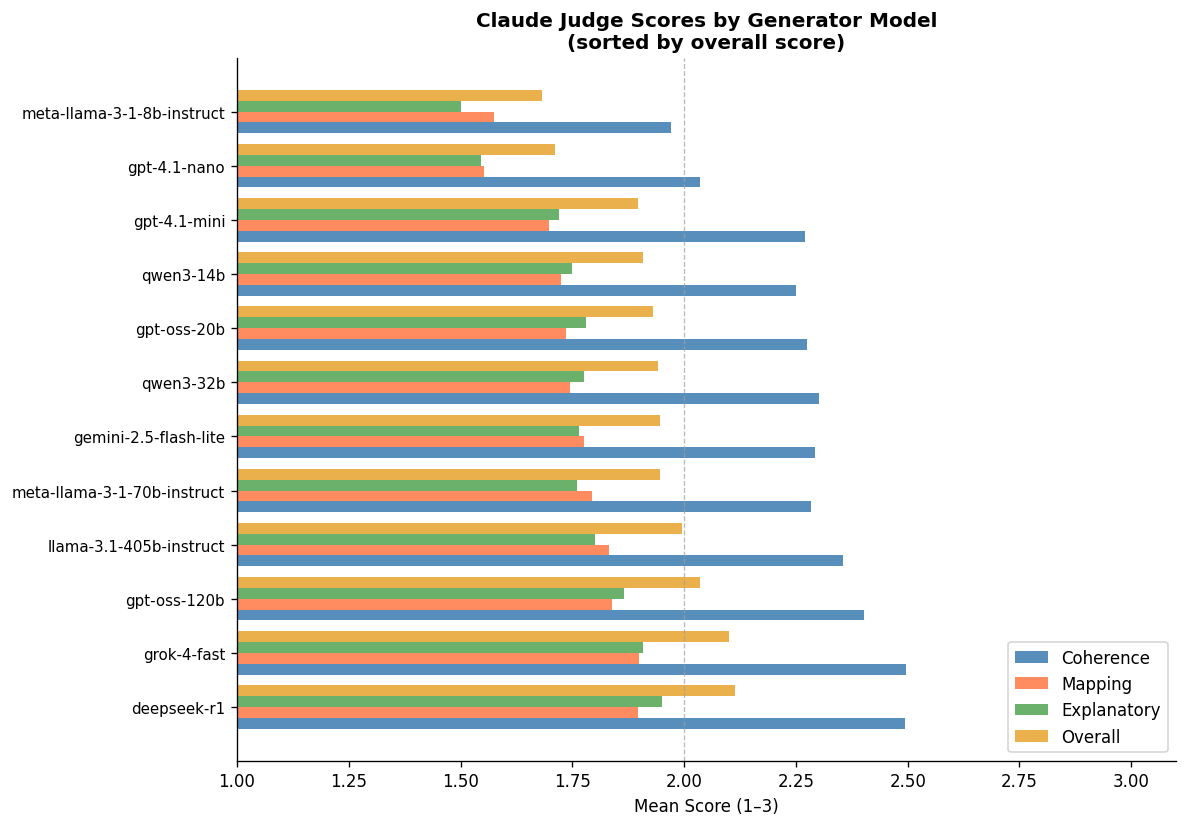

In [ ]:
# ── Horizontal grouped bar chart ─────────────────────────────────────────────
model_order = model_agg['model'].tolist()  # already sorted by Overall
y = np.arange(len(model_order))
height = 0.2

fig, ax = plt.subplots(figsize=(10, 7))
dim_colors = [STEEL, CORAL, GREEN, AMBER]
dim_keys   = ['Coherence', 'Mapping', 'Explanatory', 'Overall']

for i, (dk, color) in enumerate(zip(dim_keys, dim_colors)):
    vals = model_agg.set_index('model').loc[model_order, dk].values
    ax.barh(y + i*height, vals, height, label=dk, color=color, alpha=0.9)

ax.set_yticks(y + 1.5*height)
ax.set_yticklabels(model_order, fontsize=9)
ax.set_xlim(1, 3.1)
ax.axvline(2, color=GRAY, linestyle='--', linewidth=0.8, alpha=0.7)
ax.set_xlabel('Mean Score (1–3)')
ax.set_title('Claude Judge Scores by Generator Model\n(sorted by overall score)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, 'claude_model_scores_overall.png'), dpi=150, bbox_inches='tight')
plt.show()

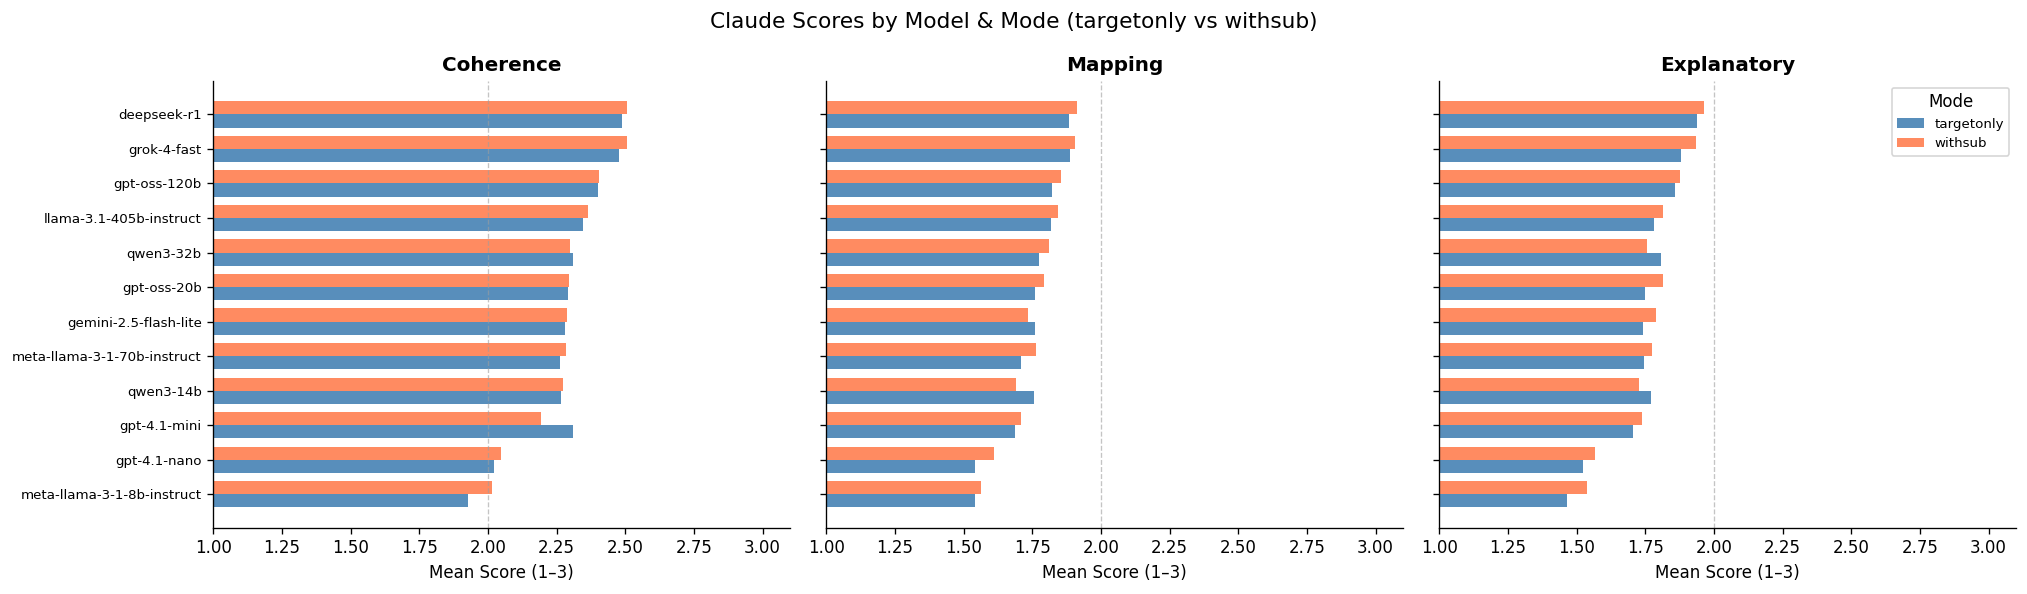

In [ ]:
# ── 5B: Faceted by dimension, grouped by model & mode ────────────────────────
mode_model_agg = (
    llm_claude.groupby(['model','original_mode'])
    .agg(
        Coherence   = ('analogy_coherence', 'mean'),
        Mapping     = ('mapping_soundness',  'mean'),
        Explanatory = ('explanatory_power',  'mean'),
        Overall     = ('average_score',      'mean'),
    )
    .reset_index()
    .round(3)
)

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
modes = ['targetonly', 'withsub']
mode_colors = [STEEL, CORAL]

for ax, dim in zip(axes, ['Coherence','Mapping','Explanatory']):
    pivot_mm = mode_model_agg.pivot(index='model', columns='original_mode', values=dim)
    # Sort by mean of both modes
    pivot_mm = pivot_mm.loc[pivot_mm.mean(axis=1).sort_values(ascending=True).index]

    y_mm = np.arange(len(pivot_mm))
    w = 0.38
    for i, (mode, color) in enumerate(zip(modes, mode_colors)):
        if mode in pivot_mm.columns:
            ax.barh(y_mm + i*w, pivot_mm[mode].values, w,
                    label=mode, color=color, alpha=0.9)

    ax.set_yticks(y_mm + w/2)
    ax.set_yticklabels(pivot_mm.index, fontsize=8)
    ax.set_xlim(1, 3.1)
    ax.axvline(2, color=GRAY, linestyle='--', linewidth=0.8, alpha=0.6)
    ax.set_title(dim)
    ax.set_xlabel('Mean Score (1–3)')
    if ax == axes[-1]:
        ax.legend(title='Mode', fontsize=8)

fig.suptitle('Claude Scores by Model & Mode (targetonly vs withsub)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, 'claude_scores_by_mode.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 5C: Analogy type breakdown (baseline → embedding → rerank) ───────────────
type_agg = (
    llm_claude[llm_claude['analogy_type'].isin(['baseline','embedding','rerank'])]
    .groupby('analogy_type')[['analogy_coherence','mapping_soundness','explanatory_power','average_score']]
    .agg(['mean','std'])
    .round(3)
)
print('=== Score by Analogy Type ===')
type_agg

=== Score by Analogy Type ===


analogy_coherence        mapping_soundness         \
                          mean    std              mean    std   
analogy_type                                                     
baseline                 2.463  0.652             1.839  0.560   
embedding                1.956  0.748             1.550  0.583   
rerank                   2.437  0.677             1.878  0.561   

             explanatory_power        average_score         
                          mean    std          mean    std  
analogy_type                                                
baseline                 1.902  0.622         2.068  0.541  
embedding                1.484  0.581         1.663  0.575  
rerank                   1.894  0.640         2.069  0.550

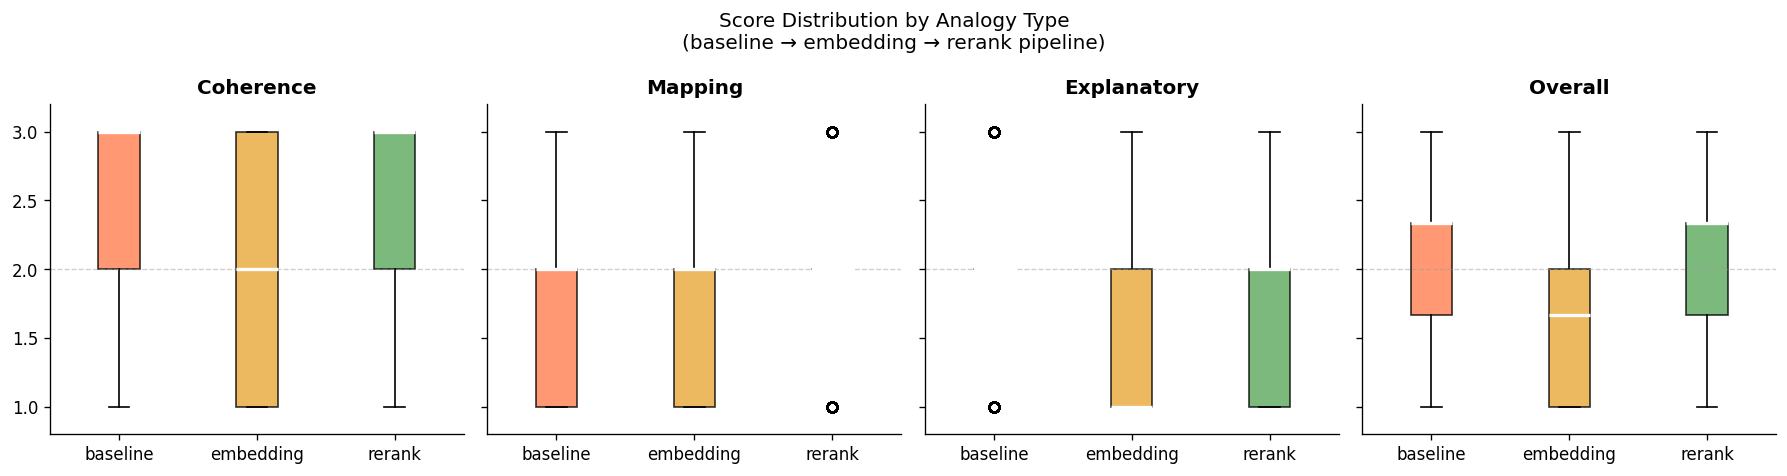

In [ ]:
# Box plots per analogy type
plot_data = llm_claude[llm_claude['analogy_type'].isin(['baseline','embedding','rerank'])].copy()
type_order = ['baseline', 'embedding', 'rerank']
type_colors = [CORAL, AMBER, GREEN]

fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=True)
col_map = {
    'Coherence'  : 'analogy_coherence',
    'Mapping'    : 'mapping_soundness',
    'Explanatory': 'explanatory_power',
    'Overall'    : 'average_score',
}

for ax, (label, col) in zip(axes, col_map.items()):
    data_by_type = [plot_data[plot_data['analogy_type'] == t][col].dropna().values
                    for t in type_order]
    bp = ax.boxplot(data_by_type, labels=type_order, patch_artist=True,
                    medianprops={'color': 'white', 'linewidth': 2})
    for patch, color in zip(bp['boxes'], type_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_title(label)
    ax.set_ylim(0.8, 3.2)
    ax.axhline(2, color=GRAY, linestyle='--', linewidth=0.8, alpha=0.5)

fig.suptitle('Score Distribution by Analogy Type\n(baseline → embedding → rerank pipeline)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, 'score_by_analogy_type.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 5D: Final Leaderboard ─────────────────────────────────────────────────────
leaderboard = (
    llm_claude.groupby(['model','original_mode'])
    .agg(
        Coherence   = ('analogy_coherence', 'mean'),
        Mapping     = ('mapping_soundness',  'mean'),
        Explanatory = ('explanatory_power',  'mean'),
        Overall     = ('average_score',      'mean'),
        N           = ('average_score',      'count'),
    )
    .reset_index()
    .sort_values('Overall', ascending=False)
    .reset_index(drop=True)
)
leaderboard.insert(0, 'Rank', leaderboard.index + 1)
leaderboard = leaderboard.round(3)

print('=== Claude Judge Final Leaderboard (Model × Mode) ===')
leaderboard

=== Claude Judge Final Leaderboard (Model × Mode) ===


,Rank,model,original_mode,Coherence,Mapping,Explanatory,Overall,N
0,1,deepseek-r1,withsub,2.507,1.907,1.965,2.126,962
1,2,grok-4-fast,withsub,2.505,1.914,1.936,2.118,963
2,3,deepseek-r1,targetonly,2.478,1.888,1.937,2.101,962
3,4,grok-4-fast,targetonly,2.489,1.884,1.880,2.084,963
4,5,gpt-oss-120b,withsub,2.403,1.856,1.875,2.045,960
5,6,gpt-oss-120b,targetonly,2.402,1.820,1.857,2.027,947
6,7,llama-3.1-405b-instruct,withsub,2.366,1.843,1.816,2.008,963
7,8,llama-3.1-405b-instruct,targetonly,2.345,1.818,1.783,1.982,963
8,9,gemini-2.5-flash-lite,withsub,2.296,1.792,1.789,1.959,963
9,10,qwen3-32b,targetonly,2.308,1.761,1.807,1.959,633


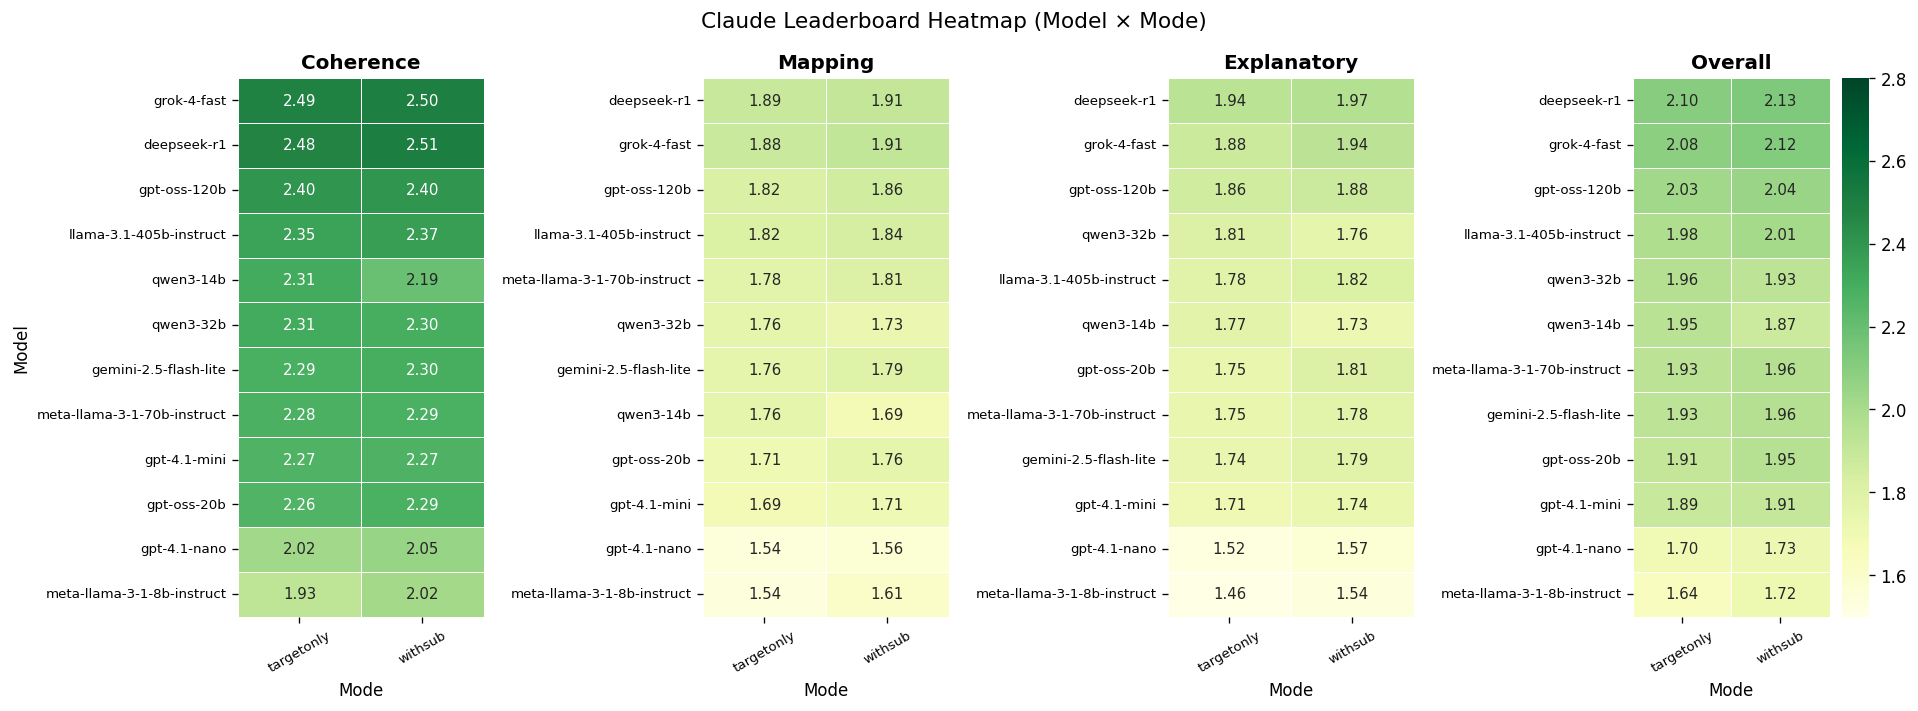


All figures saved to: d:\My_working_area\Masters\Thesis\code\Toward-Usable-Scientific-Analogies\Toward-Usable-Scientific-Analogies\stage_2_Modular_solution\LLM\notebooks\..\results\human_annotation


In [ ]:
# ── Heatmap leaderboard (model × mode for each dimension) ────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 6))

for ax, dim in zip(axes, ['Coherence','Mapping','Explanatory','Overall']):
    heat = leaderboard.pivot(index='model', columns='original_mode', values=dim)
    heat = heat.sort_values(heat.columns.tolist()[0], ascending=False)
    sns.heatmap(heat, annot=True, fmt='.2f', cmap='YlGn',
                vmin=1.5, vmax=2.8, linewidths=0.5, ax=ax,
                cbar=ax == axes[-1], annot_kws={'size': 9})
    ax.set_title(dim)
    ax.set_xlabel('Mode')
    ax.set_ylabel('Model' if ax == axes[0] else '')
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)

fig.suptitle('Claude Leaderboard Heatmap (Model × Mode)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, 'claude_leaderboard_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\nAll figures saved to: {RES_DIR}')